In [2]:
%pip install "kagglehub[pandas-datasets]"
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sohier/calcofi")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Path to dataset files: C:\Users\mcken\.cache\kagglehub\datasets\sohier\calcofi\versions\2


In [3]:
%pip install -q scipy
%pip install -q scikit-learn
%pip install -q xgboost
%pip install -q tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor, RidgeCV
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.neural_network import MLPRegressor
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import QuantileTransformer
import joblib

In [5]:
folder_path = path
files = os.listdir(folder_path)
print("Files in the dataset folder:", files)

Files in the dataset folder: ['bottle.csv', 'cast.csv']


In [6]:
bottle_df = pd.read_csv(os.path.join(folder_path, 'bottle.csv'), low_memory=False)
bottle_df.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
cast_df = pd.read_csv(os.path.join(folder_path, 'cast.csv'))
cast_df.head()

C:\Users\mcken\AppData\Local\Temp\ipykernel_3460\502070747.py:1: DtypeWarning: Columns (0: Data_Or, 1: Cruz_Num, 2: Inc_Str, 3: Inc_End, 4: PST_LAN, 5: Civil_T) have mixed types. Specify dtype option on import or set low_memory=False.
  cast_df = pd.read_csv(os.path.join(folder_path, 'cast.csv'))


,Cst_Cnt,Cruise_ID,Cruise,Cruz_Sta,DbSta_ID,Cast_ID,Sta_ID,Quarter,Sta_Code,Distance,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
0,1,1949-03-01-C-31CR,194903,19490305400560,5400560,19-4903CR-HY-060-0930-05400560,054.0 056.0,1,NST,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
1,2,1949-03-01-C-31CR,194903,19490305200750,5200750,19-4903CR-HY-060-2112-05200750,052.0 075.0,1,NST,NaN,...,NaN,16.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN
2,3,1949-03-01-C-31CR,194903,19490305100850,5100850,19-4903CR-HY-061-0354-05100850,051.0 085.0,1,NST,NaN,...,NaN,23.0,5.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN
3,4,1949-03-01-C-31CR,194903,19490305000950,5000950,19-4903CR-HY-061-1042-05000950,050.0 095.0,1,NST,NaN,...,NaN,18.0,8.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4,5,1949-03-01-C-31CR,194903,19490305001040,5001040,19-4903CR-HY-061-1706-05001040,050.0 104.0,1,NST,NaN,...,NaN,27.0,13.0,NaN,NaN,NaN,7.0,NaN,NaN,NaN


**Project overview.**

**Objective.**               
The goal of this project is to investigate the relationship between oceanographic measurements and water temperature and to develop machine learning models for predicting water temperature.

**Research Question.**  
Can water temperature (`T_degC`) be accurately predicted using depth (`Depthm`), salinity (`Salnty`), and dissolved oxygen (`O2ml_L`)?

**Dataset.**  
The analysis is based on the CalCOFI dataset, which contains oceanographic measurements collected off the coast of California.

**The project includes:**  
- exploratory data analysis;  
- data preprocessing;  
- feature analysis and transformation;  
- regression model development;  
- model comparison;  
- final model evaluation on the test set.

**Task 1. — Salinity and Water Temperature.**  
The task is to investigate the relationship between water salinity and
water temperature and determine whether water temperature can be
predicted based on salinity.

**Research Questions:**  
1. Is there a relationship between water salinity (`Salnty`) and water
   temperature (`T_degC`)?
2. Can water temperature be predicted based on salinity?

**Overview of the dataset.**  
Context.  
The California Cooperative Oceanic Fisheries Investigations (CalCOFI) are a unique partnership of the California Department of Fish & Wildlife, NOAA Fisheries Service and Scripps Institution of Oceanography. The organization was formed in 1949 to study the ecological aspects of the sardine population collapse off California. Today our focus has shifted to the study of the marine environment off the coast of California, the management of its living resources, and monitoring the indicators of El Nino and climate change. CalCOFI conducts quarterly cruises off southern & central California, collecting a suite of hydrographic and biological data on station and underway. Data collected at depths down to 500 m include: temperature, salinity, oxygen, phosphate, silicate, nitrate and nitrite, chlorophyll, transmissometer, PAR, C14 primary productivity, phytoplankton biodiversity, zooplankton biomass, and zooplankton biodiversity.

Exploratory data analysis.

In [8]:
df_tsd = bottle_df[['Depthm', 'Salnty', 'T_degC', 'O2ml_L']]
df_tsd.head()

,Depthm,Salnty,T_degC,O2ml_L
0,0,33.440,10.50,NaN
1,8,33.440,10.46,NaN
2,10,33.437,10.46,NaN
3,19,33.420,10.45,NaN
4,20,33.421,10.45,NaN


In [9]:
df_tsd.info()

<class 'pandas.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Depthm  864863 non-null  int64  
 1   Salnty  817509 non-null  float64
 2   T_degC  853900 non-null  float64
 3   O2ml_L  696201 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 26.4 MB


To get an initial overview of the numerical variables, we use
`describe()`.

In [10]:
df_tsd.describe()

,Depthm,Salnty,T_degC,O2ml_L
count,864863.000000,817509.000000,853900.000000,696201.000000
mean,226.831951,33.840350,10.799677,3.392468
std,316.050259,0.461843,4.243825,2.073256
min,0.000000,28.431000,1.440000,-0.010000
25%,46.000000,33.488000,7.680000,1.360000
50%,125.000000,33.863000,10.060000,3.440000
75%,300.000000,34.196900,13.880000,5.500000
max,5351.000000,37.034000,31.140000,11.130000


In [11]:
#Checking for missing values in the dataset
print(f'Missing values in every column, %:\n{(100 * df_tsd.isnull().sum()/df_tsd.shape[0]).round(2)}\n')
print(f'Total missing values in the dataset:\n{(100 * df_tsd.isnull().sum().sum()/df_tsd.size).round(2)}%')

Missing values in every column, %:
Depthm     0.00
Salnty     5.48
T_degC     1.27
O2ml_L    19.50
dtype: float64

Total missing values in the dataset:
6.56%


Checking the relationship between salinity and temperature.  
First, we examine the relationship between `Salnty` and `T_degC`
using a scatter plot and Pearson correlation.  
To investigate the relationship between `Salnty` and `T_degC`, we remove observations with missing values in either variable and then use a scatter plot and Pearson correlation coefficient.

In [12]:
df_st = df_tsd[['Salnty', 'T_degC']].dropna()


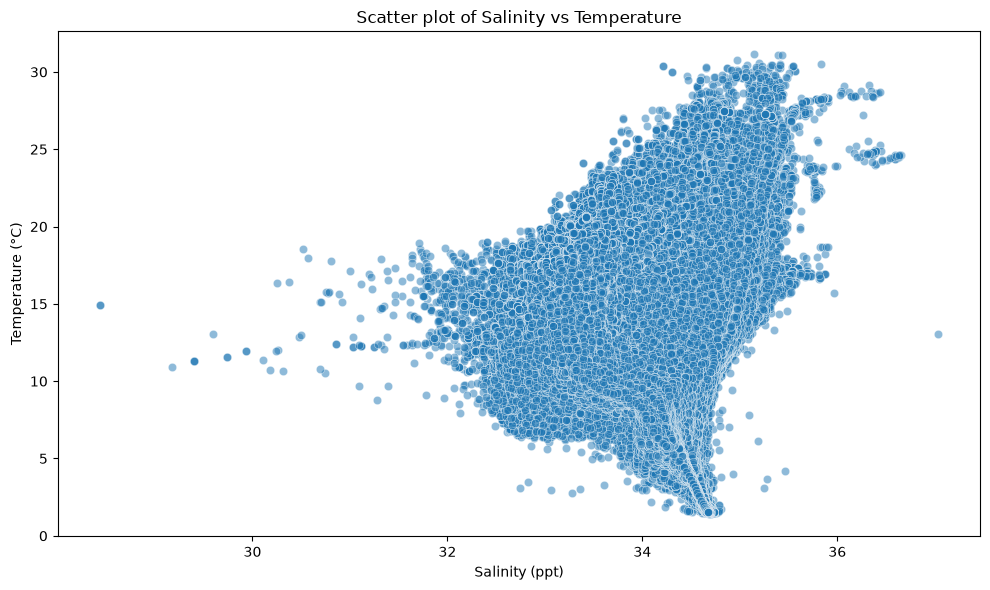

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_st, x='Salnty', y = 'T_degC', alpha = 0.5)
plt.title('Scatter plot of Salinity vs Temperature')
plt.xlabel('Salinity (ppt)')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

In [14]:
pearson_coef, p_value = stats.pearsonr(df_st['Salnty'], df_st['T_degC'])
print(f"Pearson correlation and P-value coefficients between Salinity and Temperature: {pearson_coef}, {p_value}")

Pearson correlation and P-value coefficients between Salinity and Temperature: -0.5052659661915728, 0.0


The Pearson correlation coefficient between salinity and water temperature is -0.5053, indicating a moderate negative linear
relationship between the two variables.
The p-value is effectively zero, indicating that the observed correlation is statistically significant. However, the scatter plot suggests that the relationship is not purely linear. This indicates that linear regression may not fully explain the relationship between salinity and water temperature. Therefore, non-linear models will also be considered.  
To make it more explicit let's plot a regression line.

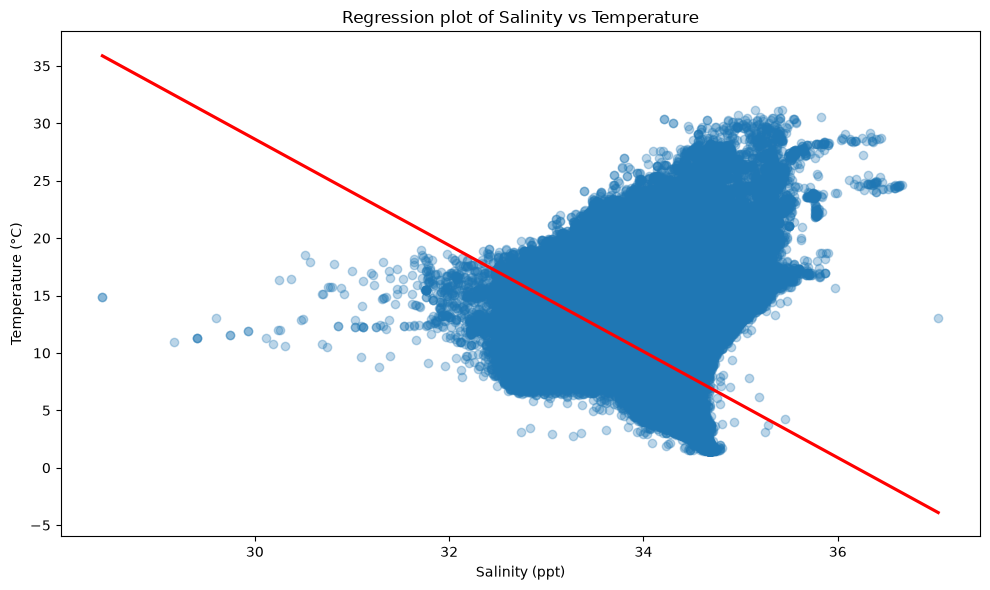

In [15]:
plt.figure(figsize=(10,6))
sns.regplot(data = df_st, x = 'Salnty', y = 'T_degC', scatter_kws = {'alpha': 0.3}, line_kws = {'color': 'red'})
plt.title('Regression plot of Salinity vs Temperature')
plt.xlabel('Salinity (ppt)')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

Although the plots above suggest that the relationship between salinity and water temperature is not purely linear, Pearson correlation indicates a moderate linear association between the variables.
Therefore, I first build a Linear Regression model as a baseline. This provides a simple reference point for evaluating whether more complex
non-linear models can better capture the relationship between salinity and water temperature.

Let's see how the data is distributed.

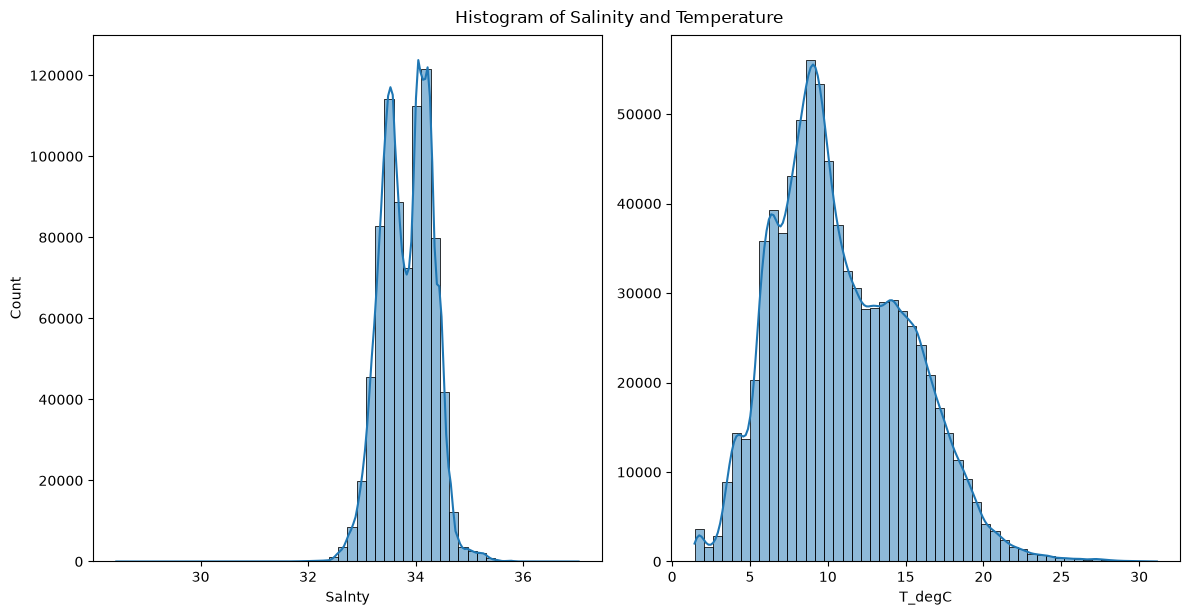

In [16]:
fig = plt.figure(figsize = (12,6))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)
sns.histplot(data = df_st, x = 'Salnty', ax = ax0, kde = True, bins = 50)
sns.histplot(data = df_st, x = 'T_degC', ax = ax1, kde = True, bins = 50)
ax1.set_ylabel('')
fig.text(0.52, 0.995, 'Histogram of Salinity and Temperature', fontsize = 12, ha = 'center')
plt.tight_layout()
plt.show()

In [17]:
print(f"A skewness of the Salinity distribution: {df_st['Salnty'].skew()}")
print(f"A skewness of the Temperature distribution: {df_st['T_degC'].skew()}")

A skewness of the Salinity distribution: -0.05549737795045546
A skewness of the Temperature distribution: 0.4949283991512483


The histograms of salinity (`Salnty`) and water temperature (`T_degC`) show that neither variable follows a normal distribution. However, normality of the predictor and target variables is not a requirement for Linear Regression. For the classical assumptions of linear regression, normality concerns the residuals rather than the input variables themselves.
Therefore, the non-normal distributions of salinity and water temperature do not prevent us from fitting a Linear Regression model.

Next, I examine the data for potential outliers in salinity and water temperature.
Identifying extreme observations is important because they can have a substantial influence on the fitted regression line and, consequently, on model performance.

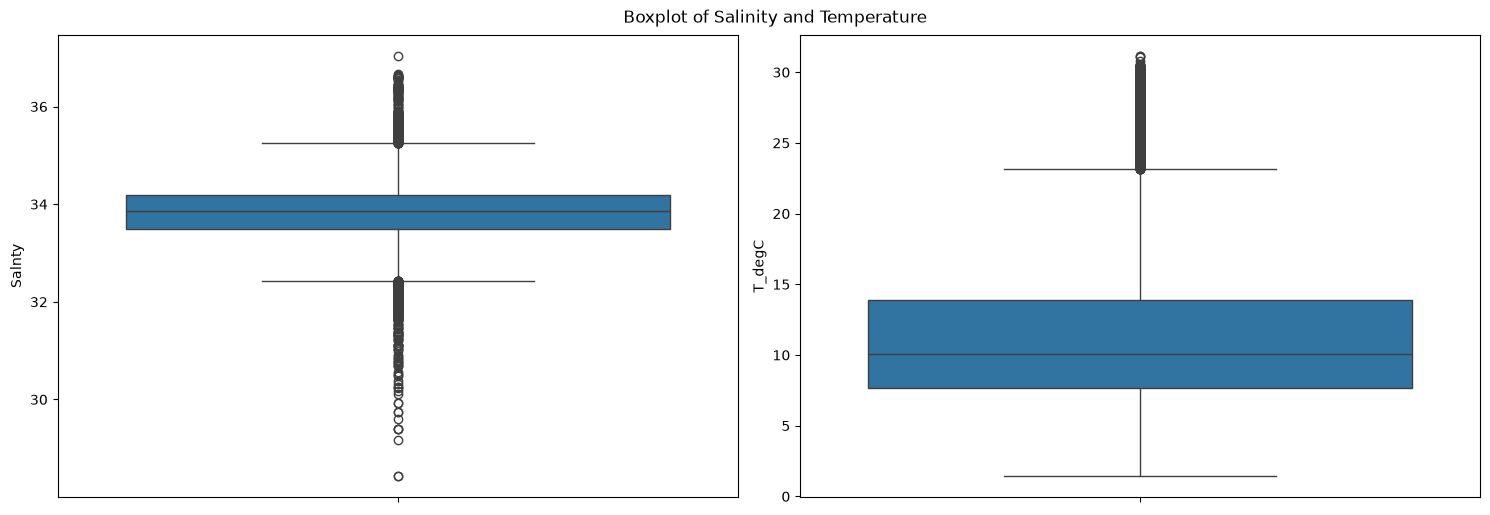

In [18]:
fig = plt.figure(figsize = (15,5))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)
sns.boxplot(data = df_tsd, y = 'Salnty', ax = ax0)
sns.boxplot(data = df_tsd, y = 'T_degC', ax = ax1)
fig.text(0.52, 0.995, 'Boxplot of Salinity and Temperature', fontsize = 12, ha = 'center')
plt.tight_layout()
plt.show()

The boxplots show potential outliers in both salinity (`Salnty`) and water temperature (`T_degC`). This is also consistent with the histograms.
For `T_degC`, the presence of extreme values results in a longer right tail, indicating a right-skewed distribution. For `Salnty`, potential outliers are present on both sides of the distribution, producing longer tails on both ends of the histogram.  
These observations are important for the regression analysis, as extreme values can have a strong influence on the fitted regression line. Therefore, their impact on the Linear Regression model should be evaluated before deciding whether any observations should be removed.

In [19]:
def outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [20]:
df_salnty_outliers = outliers(df_tsd, 'Salnty')
df_temp_outliers = outliers(df_tsd, 'T_degC')
print(f"Number of outliers in Salnty: {df_salnty_outliers.shape[0]}")
print(f"Number of outliers in T_degC: {df_temp_outliers.shape[0]}")

Number of outliers in Salnty: 2550
Number of outliers in T_degC: 3738


In [21]:
print("Statistical summary of Salnty outliers:")
display(df_salnty_outliers.describe())
print("Statistical summary of T_degC outliers:")
display(df_temp_outliers.describe())

Statistical summary of Salnty outliers:


,Depthm,Salnty,T_degC,O2ml_L
count,2550.000000,2550.000000,2530.000000,1948.000000
mean,24.234118,34.510674,19.529557,4.992058
std,38.020174,1.567072,5.025919,1.013551
min,0.000000,28.431000,3.690000,0.770000
25%,9.000000,32.390000,16.132500,4.390000
50%,20.000000,35.320000,18.425000,5.030000
75%,30.000000,35.430000,23.690000,5.760000
max,1056.000000,37.034000,31.120000,8.710000


Statistical summary of T_degC outliers:


,Depthm,Salnty,T_degC,O2ml_L
count,3738.000000,3618.000000,3738.000000,3220.000000
mean,18.033975,34.765334,25.329597,4.598625
std,16.446219,0.509929,1.726386,0.488020
min,0.000000,33.393000,23.190000,2.010000
25%,5.000000,34.437000,23.910000,4.420000
50%,11.000000,34.690000,24.880000,4.660000
75%,30.000000,35.152500,26.520000,4.860000
max,100.000000,36.658000,31.140000,6.720000


In [22]:
print("Max value of Salinity outliers:")
display(df_salnty_outliers.loc[df_salnty_outliers['Salnty'].idxmax()])
print("Min value of Salnty outliers:")
display(df_salnty_outliers.loc[df_salnty_outliers['Salnty'].idxmin()])
print("Max value of Temperature outliers:")
display(df_temp_outliers.loc[df_temp_outliers['T_degC'].idxmax()])
print("Min value of Temperature outliers:")
display(df_temp_outliers.loc[df_temp_outliers['T_degC'].idxmin()])

Max value of Salinity outliers:


Depthm    10.000
Salnty    37.034
T_degC    13.080
O2ml_L     6.220
Name: 564387, dtype: float64

Min value of Salnty outliers:


Depthm     0.000
Salnty    28.431
T_degC    14.910
O2ml_L       NaN
Name: 769299, dtype: float64

Max value of Temperature outliers:


Depthm     0.00
Salnty    35.15
T_degC    31.14
O2ml_L     4.56
Name: 238476, dtype: float64

Min value of Temperature outliers:


Depthm    20.000
Salnty    34.483
T_degC    23.190
O2ml_L       NaN
Name: 18618, dtype: float64

Temperature of water of 31.14 by Depth 0 looks a bit off. Let's investigate it more carefully.

In [23]:
display(bottle_df.loc[bottle_df['Salnty'] == 37.034])
display(bottle_df.loc[bottle_df['T_degC'] == 31.14])

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
564387,22937,564388,065.0 055.0,19-8402JD-10-041-1139-06500550-0010A-3,10,13.08,37.034,6.22,27.954,106.5,...,0.16,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
238476,9117,238477,139.0 085.0,19-5708ST-HY-224-2318-13900850-0000B-3,0,31.14,35.15,4.56,21.447,106.7,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
bottle_df[bottle_df['Cst_Cnt'] == 22937][['Depthm', 'Salnty', 'T_degC', 'O2ml_L']].sort_values('Depthm')

,Depthm,Salnty,T_degC,O2ml_L
564387,10,37.034,13.08,6.22


In [25]:
bottle_df[bottle_df['Depthm'] == 10][['Cst_Cnt', 'Depthm', 'Salnty', 'T_degC', 'O2ml_L']].sort_values('Salnty', ascending=False)

,Cst_Cnt,Depthm,Salnty,T_degC,O2ml_L
564387,22937,10,37.034,13.08,6.22
475390,19002,10,36.605,24.51,NaN
475413,19008,10,36.592,24.62,4.28
475386,19001,10,36.589,24.35,4.38
475409,19007,10,36.580,24.52,4.47
...,...,...,...,...,...
791418,31583,10,NaN,15.72,NaN
797789,31812,10,NaN,17.10,NaN
810515,32287,10,NaN,14.88,NaN
810524,32288,10,NaN,15.10,NaN


In [26]:
bottle_df[bottle_df['Cst_Cnt'] == 9117][['Depthm', 'Salnty', 'T_degC', 'O2ml_L']].sort_values('Depthm')

,Depthm,Salnty,T_degC,O2ml_L
238476,0,35.150,31.14,4.56
238477,10,35.070,30.46,4.31
238478,20,35.050,30.25,4.31
238479,29,35.020,29.94,4.31
238480,30,35.010,29.86,4.32
238481,39,34.910,28.86,4.39
238482,46,34.760,NaN,4.78
238483,50,34.775,26.92,4.71
238484,58,34.730,25.32,4.57
238485,67,34.780,23.68,3.92


Although Salnty and T_degC contain statistical outliers, these observations do not appear to be erroneous measurements. Therefore, they should be retained in the dataset.

LinearRegression.

Since only 1.27% of the values in T_degC are missing, it is reasonable to remove these observations for supervised learning.

In [27]:
df_tsd_copy = df_tsd.dropna(subset = ['T_degC'])

In [28]:
X = df_tsd_copy[['Salnty']]
y = df_tsd_copy[['T_degC']]

In [29]:
X_train, X_, y_train, y_ = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_, y_, test_size = 0.5, random_state = 42)

In [30]:
sgd_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler()),
    ('regressor', SGDRegressor(
        loss = 'squared_error',
        penalty = 'l2',
        alpha = 0.01,
        max_iter = 1000,
        tol = 1e-3,
        learning_rate = 'optimal',
        random_state = 1
    ))
])

In [31]:
sgd_pipeline.fit(X_train, y_train)
y_val_pred = sgd_pipeline.predict(X_val)

c:\Users\mcken\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [32]:
linear_metrics = []
linear_metrics.append({
    'Val_R2': r2_score(y_val, y_val_pred),
    'Val_RMSE': mean_squared_error(y_val, y_val_pred) ** 0.5,
    'Val_MAE': mean_absolute_error(y_val, y_val_pred)
})
linear_metrics_df = pd.DataFrame(linear_metrics)
linear_metrics_df

,Val_R2,Val_RMSE,Val_MAE
0,0.2449,3.688867,2.717505


Results.    
As expected, the Linear Regression model showed relatively weak performance. The model explains only about 24% of the variance in the target variable (T_degC). The RMSE of approximately 3.69 °C and the MAE of 2.72 °C indicate that the model's prediction errors are relatively large.

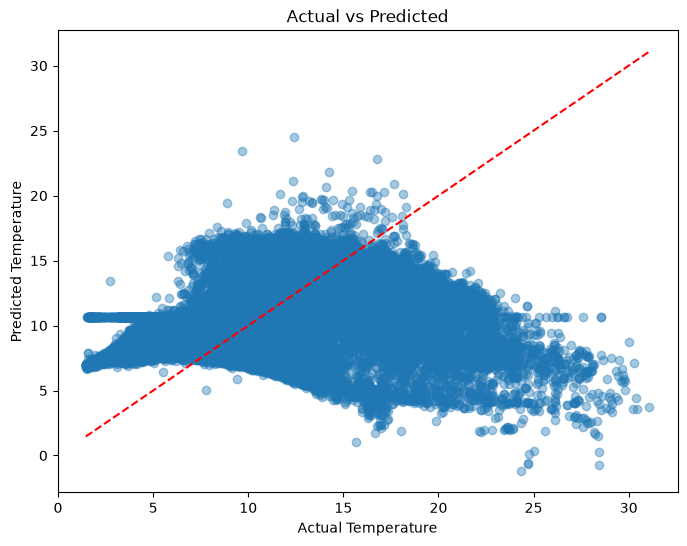

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--'
)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted')

plt.show()

As shown above the linear regression isn't the best model for predicting temperature based on salnity.

In [34]:
import joblib

In [35]:
joblib.dump(sgd_pipeline, 'sgd_pipeline.pkl')

['sgd_pipeline.pkl']

Polynomial Regression

In [36]:
results_poly = []
for n in range(2,37):
    poly_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('pre-scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree = n, include_bias = False)),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])
    poly_pipeline.fit(X_train, y_train)
    y_val_pred = poly_pipeline.predict(X_val)
    Val_r2 = r2_score(y_val, y_val_pred)
    Val_rmse = mean_squared_error(y_val, y_val_pred) ** 0.5
    Val_mae = mean_absolute_error(y_val, y_val_pred)
    results_poly.append({
        'degree': n,
        'Val_R2': Val_r2,
        'Val_RMSE': Val_rmse,
        'Val_MAE': Val_mae
    })
results_poly_df = pd.DataFrame(results_poly)

Before generating polynomial features, I decided to scale the original features using StandardScaler().
This is especially important when working with higher polynomial degrees. Without pre-scaling, features with large values can produce extremely large values after polynomial expansion. For example, a feature with a value of 5,000 becomes 25 million at degree 2 and 125 billion at degree 3.

In [37]:
results_poly_df

,degree,Val_R2,Val_RMSE,Val_MAE
0,2,0.261627,3.647780,2.686120
1,3,0.330540,3.473386,2.533729
2,4,0.365091,3.382567,2.450761
3,5,0.374069,3.358567,2.418724
4,6,0.403780,3.277889,2.334339
5,7,0.405667,3.272696,2.336607
6,8,0.416050,3.243985,2.305434
7,9,0.421154,3.229775,2.298951
8,10,0.423271,3.223863,2.288585
9,11,0.427141,3.213029,2.281843


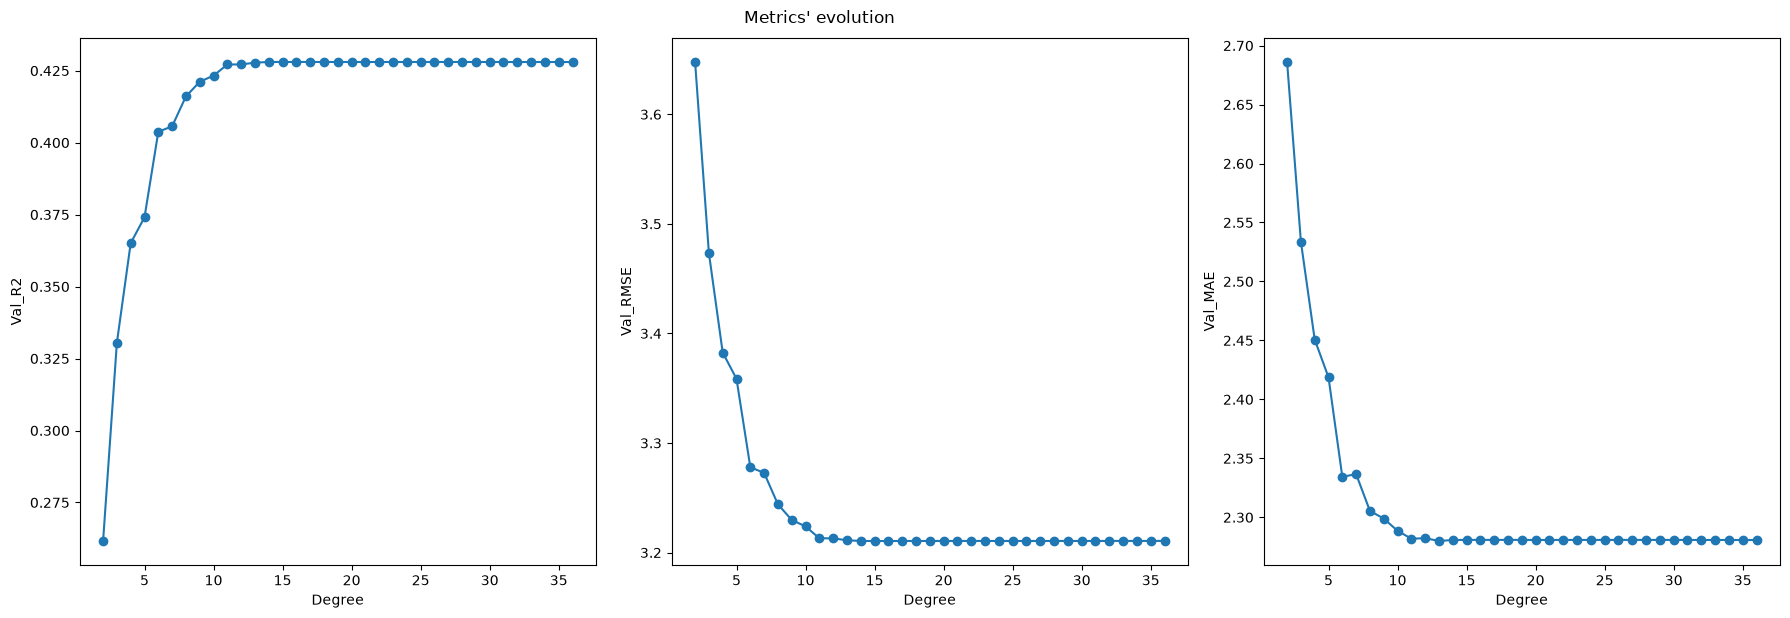

In [38]:
fig = plt.figure(figsize=(18,6))
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)
ax0.plot(results_poly_df['degree'], results_poly_df['Val_R2'], 
         marker = 'o')
ax1.plot(results_poly_df['degree'], results_poly_df['Val_RMSE'], 
         marker = 'o')
ax2.plot(results_poly_df['degree'], results_poly_df['Val_MAE'], 
         marker = 'o')
ax0.set_xlabel('Degree')
ax0.set_ylabel('Val_R2')
ax1.set_xlabel('Degree')
ax1.set_ylabel('Val_RMSE')
ax2.set_xlabel('Degree')
ax2.set_ylabel('Val_MAE')
fig.text(0.5, 1, "Metrics' evolution", ha = "right", fontsize = 12)
fig.tight_layout()
plt.show()

In [39]:
best_degree_val_df = results_poly_df.loc[(results_poly_df['Val_R2'] == results_poly_df['Val_R2'].max()) 
                                 & (results_poly_df['Val_RMSE'] == results_poly_df['Val_RMSE'].min())]
best_degree_val_df

,degree,Val_R2,Val_RMSE,Val_MAE
13,15,0.428024,3.210552,2.28086


In [40]:
poly_pipeline_best = Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('pre-scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree = 33, include_bias = False)),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])
poly_pipeline_best.fit(X_train, y_train)
y_val_pred = poly_pipeline_best.predict(X_val)

In [41]:
results_poly_best_val = []
results_poly_best_val.append({
    'Val_r2': r2_score(y_val, y_val_pred),
    'Val_rmse': mean_squared_error(y_val, y_val_pred) ** 0.5,
    'Val_mae': mean_absolute_error(y_val, y_val_pred)
})
results_poly_best_val_df = pd.DataFrame(results_poly_best_val)


In [42]:
print("Linear model metrics:")
display(linear_metrics_df)
print("Polynomial regression model metrics:")
display(results_poly_best_val_df)

Linear model metrics:


,Val_R2,Val_RMSE,Val_MAE
0,0.2449,3.688867,2.717505


Polynomial regression model metrics:


,Val_r2,Val_rmse,Val_mae
0,0.428004,3.210609,2.280795


As shown above, the Polynomial Regression model provides a noticeable improvement in performance compared with the Linear Regression baseline.
The R^2 score increased from 0.245 to 0.428, while RMSE decreased from 3.69 °C to 3.21 °C and MAE from 2.72 °C to 2.28 °C. This indicates that the Polynomial Regression model captures a substantially larger proportion of the variation in water temperature and produces more accurate predictions.

In [43]:
y_val_pred = y_val_pred.ravel()
plot_data_poly_best = pd.DataFrame({
    'Salnty': X_val['Salnty'].values,
    'y_pred': y_val_pred
}).sort_values('Salnty')

In [44]:
y_val_pred[0:5]

array([12.59301247, 13.48234075,  7.76546436, 14.09034225, 14.10437302])

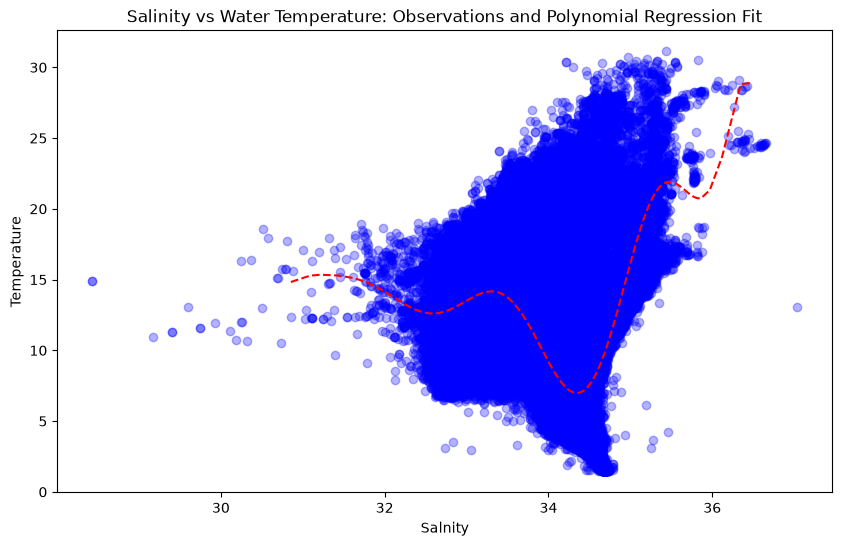

In [45]:
plt.figure(figsize=(10,6))
plt.scatter(X_train['Salnty'], y_train, color = 'blue', alpha = 0.3)
plt.plot(plot_data_poly_best['Salnty'], plot_data_poly_best['y_pred'], '--r')
plt.xlabel('Salnity')
plt.ylabel('Temperature')
plt.title('Salinity vs Water Temperature: Observations and Polynomial Regression Fit')
plt.show()

Let us check the model for overfitting.

In [46]:
y_train_pred = poly_pipeline_best.predict(X_train)
results_poly_train = []
results_poly_train.append({
    'Train_r2': r2_score(y_train, y_train_pred),
    'Train_rmse': mean_squared_error(y_train, y_train_pred) ** 0.5,
    'Train_mae': mean_absolute_error(y_train, y_train_pred)
})
results_poly_train_df = pd.DataFrame(results_poly_train)
results_poly_train_df

,Train_r2,Train_rmse,Train_mae
0,0.427714,3.211857,2.281836


In [47]:
print('Results of the Train data:')
display(results_poly_train_df)
print('Results of the Validation data:')
display(results_poly_best_val_df)

Results of the Train data:


,Train_r2,Train_rmse,Train_mae
0,0.427714,3.211857,2.281836


Results of the Validation data:


,Val_r2,Val_rmse,Val_mae
0,0.428004,3.210609,2.280795


The close training, validation, and test metrics do not indicate substantial overfitting in this evaluation. The performance on the training and validation sets is very similar, with an R^2 of 0.429 on the training set and 0.4262 on the validation set. Similarly, the RMSE values are nearly identical (3.207 °C and 3.206 °C, respectively).
This indicates that the model generalizes well to unseen validation data.

In [48]:
joblib.dump(poly_pipeline_best, 'polynomial_regression_pipeline.pkl')

['polynomial_regression_pipeline.pkl']

Let's see whether we can improve the model's performance by moving on to a more advanced model, such as XGBoost.

In [49]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
results_xgb = []
for n in range(2,30):
    xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('regressor', XGBRegressor(
    n_estimators = 500,
    max_depth = n,
    learning_rate = 0.01,
    subsample = 0.8,
    objective = 'reg:squarederror',
    random_state = 1
    ))
    ])
    xgb_pipeline.fit(X_train, y_train)
    y_val_pred_xgb = xgb_pipeline.predict(X_val)
    results_xgb.append({
    'n-nodes': n,
    'Val_r2': r2_score(y_val, y_val_pred_xgb),
    'Val_rmse': mean_squared_error(y_val, y_val_pred_xgb) ** 0.5,
    'Val_mae': mean_absolute_error(y_val, y_val_pred_xgb)
})

In [51]:
results_xgb_df = pd.DataFrame(results_xgb)
results_xgb_df

,n-nodes,Val_r2,Val_rmse,Val_mae
0,2,0.436428,3.186880,2.283899
1,3,0.437951,3.182570,2.284119
2,4,0.438282,3.181633,2.283776
3,5,0.438621,3.180672,2.283238
4,6,0.438857,3.180004,2.282676
5,7,0.439012,3.179565,2.282542
6,8,0.439105,3.179301,2.282647
7,9,0.439142,3.179196,2.282908
8,10,0.439151,3.179172,2.283145
9,11,0.439148,3.179179,2.283305


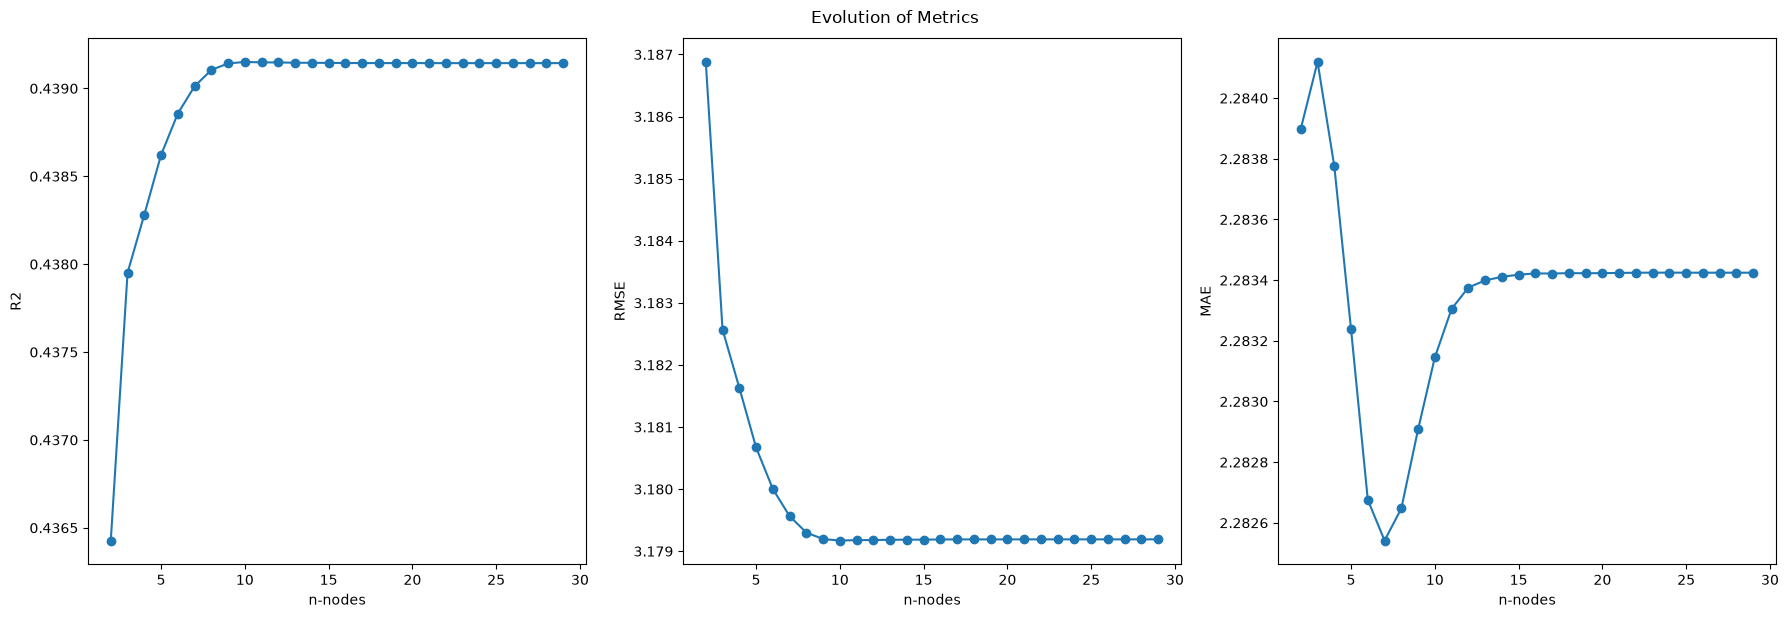

In [52]:
fig = plt.figure(figsize=(18,6))
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)
ax0.plot(results_xgb_df['n-nodes'], results_xgb_df['Val_r2'], 
         marker = 'o')
ax1.plot(results_xgb_df['n-nodes'], results_xgb_df['Val_rmse'], 
         marker = 'o')
ax2.plot(results_xgb_df['n-nodes'], results_xgb_df['Val_mae'], 
         marker = 'o')
ax0.set_xlabel('n-nodes')
ax0.set_ylabel('R2')
ax1.set_xlabel('n-nodes')
ax1.set_ylabel('RMSE')
ax2.set_xlabel('n-nodes')
ax2.set_ylabel('MAE')
fig.text(0.5, 1, 'Evolution of Metrics', ha = 'center', fontsize = 12)
fig.tight_layout()
plt.show()

In [53]:
results_xgb_best = results_xgb_df.loc[results_xgb_df['Val_mae'] == results_xgb_df['Val_mae'].min()]
results_xgb_best

,n-nodes,Val_r2,Val_rmse,Val_mae
5,7,0.439012,3.179565,2.282542


In [54]:
results_xgb_best1 = results_xgb_df.loc[results_xgb_df['Val_r2'] == results_xgb_df['Val_r2'].max()]
results_xgb_best1

,n-nodes,Val_r2,Val_rmse,Val_mae
8,10,0.439151,3.179172,2.283145


Since the models with a maximum depth of 8 and 11 have very similar validation metrics, it makes sense to choose the simpler model. A maximum depth of 8 provides nearly the same performance while keeping the model less complex, which may also help reduce the risk of overfitting.

In [55]:
results_xgb_best =[]
xgb_pipeline_best = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('regressor', XGBRegressor(
    n_estimators = 500,
    max_depth = 8,
    learning_rate = 0.01,
    subsample = 0.8,
    objective = 'reg:squarederror',
    random_state = 1
    ))
    ])
xgb_pipeline_best.fit(X_train, y_train)
y_val_pred_xgb = xgb_pipeline_best.predict(X_val)
results_xgb_best.append({
    'n-nodes': 8,
    'Val_r2': r2_score(y_val, y_val_pred_xgb),
    'Val_rmse': mean_squared_error(y_val, y_val_pred_xgb) ** 0.5,
    'Val_mae': mean_absolute_error(y_val, y_val_pred_xgb)
})

In [56]:
results_xgb_val_df = pd.DataFrame(results_xgb_best)
results_xgb_val_df

,n-nodes,Val_r2,Val_rmse,Val_mae
0,8,0.439105,3.179301,2.282647


XGBoost model shows slightly better results than Polynomial regression with R^2 of 0.4391 and RMSE of 3.179 on the Validation set.

In [57]:
print('Metrics of the Polynomial Regression:')
display(results_poly_best_val_df)
print('Metrics of the XGBoost model:')
display(results_xgb_val_df.iloc[:, 1:])

Metrics of the Polynomial Regression:


,Val_r2,Val_rmse,Val_mae
0,0.428004,3.210609,2.280795


Metrics of the XGBoost model:


,Val_r2,Val_rmse,Val_mae
0,0.439105,3.179301,2.282647


Let's check the model for overfitting.

In [58]:
results_xgb_train = []
y_train_pred_xgb = xgb_pipeline_best.predict(X_train)
r2_train = r2_score(y_train, y_train_pred_xgb)
rmse_train = mean_squared_error(y_train, y_train_pred_xgb) ** 0.5
mae_train = mean_absolute_error(y_train, y_train_pred_xgb)
results_xgb_train.append({
    'Train_r2': r2_train,
    'Train_rmse': rmse_train,
    'Train_mae': mae_train
})

results_xgb_train_df = pd.DataFrame(results_xgb_train)

In [59]:
print('Metrics of XGBoost model for Validation sample:')
display(results_xgb_val_df.iloc[:,1:])
print('Metrics of XGBoost model for Train sample:')
display(results_xgb_train_df)

Metrics of XGBoost model for Validation sample:


,Val_r2,Val_rmse,Val_mae
0,0.439105,3.179301,2.282647


Metrics of XGBoost model for Train sample:


,Train_r2,Train_rmse,Train_mae
0,0.440041,3.177077,2.281306


The close training, validation, and test metrics do not indicate substantial overfitting in this evaluation. The performance on the training and validation sets is very similar, with an R^2 of 0.44 on the training set and 0.439 on the validation set. Similarly, the RMSE values are nearly identical (3.177 °C and 3.179 °C, respectively).
This indicates that the model generalizes well to unseen validation data.

In [60]:
joblib.dump(xgb_pipeline_best, 'xgboost_pipeline.pkl')

['xgboost_pipeline.pkl']

Let's check wether we can improve results by applying K-means as feature ingeniring.

In [61]:
median_train = X_train[["Salnty"]].median()

In [62]:
kmeans = KMeans(n_clusters = 100, random_state = 1)
kmeans.fit(X_train[['Salnty']].replace(np.nan, median_train))
X_train['Salnty_cluster'] = kmeans.predict(X_train[['Salnty']].replace(np.nan, median_train))
X_val['Salnty_cluster'] = kmeans.predict(X_val[['Salnty']].replace(np.nan, median_train))

In [63]:
results_kmeans_xgb = []
for n in range(2,30):
    kmeans_xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('regressor', XGBRegressor(
    n_estimators = 500,
    max_depth = n,
    learning_rate = 0.01,
    subsample = 0.8,
    objective = 'reg:squarederror',
    random_state = 1
    ))
    ])
    kmeans_xgb_pipeline.fit(X_train, y_train)
    y_val_pred_kmeans_xgb = kmeans_xgb_pipeline.predict(X_val)
    results_kmeans_xgb.append({
    'n-nodes': n,
    'r2_kmeans_xgb': r2_score(y_val, y_val_pred_kmeans_xgb),
    'rmse_kmeans_xgb': mean_squared_error(y_val, y_val_pred_kmeans_xgb) ** 0.5,
    'mae_kmeans_xgb': mean_absolute_error(y_val, y_val_pred_kmeans_xgb)
})

In [64]:
results_kmeans_xgb_df = pd.DataFrame(results_kmeans_xgb)
results_kmeans_xgb_df

,n-nodes,r2_kmeans_xgb,rmse_kmeans_xgb,mae_kmeans_xgb
0,2,0.436436,3.186856,2.283910
1,3,0.438024,3.182363,2.283887
2,4,0.438769,3.180252,2.282557
3,5,0.439439,3.178355,2.280974
4,6,0.439824,3.177261,2.279794
5,7,0.440090,3.176508,2.279337
6,8,0.440242,3.176078,2.279296
7,9,0.440314,3.175873,2.279512
8,10,0.440333,3.175817,2.279779
9,11,0.440338,3.175804,2.279973


In [65]:
results_kmeans_xgb_bestModel = results_kmeans_xgb_df.loc[(results_kmeans_xgb_df['r2_kmeans_xgb'] == results_kmeans_xgb_df['r2_kmeans_xgb'].max())]
print('Best XGBoost model with K-means feature ingeneering based on max R^2:')
display(results_kmeans_xgb_bestModel)


Best XGBoost model with K-means feature ingeneering based on max R^2:


,n-nodes,r2_kmeans_xgb,rmse_kmeans_xgb,mae_kmeans_xgb
9,11,0.440338,3.175804,2.279973


In [66]:
results_kmeans_xgb_bestModel1 = results_kmeans_xgb_df.loc[(results_kmeans_xgb_df['mae_kmeans_xgb'] == results_kmeans_xgb_df['mae_kmeans_xgb'].min())]
print('Best XGBoost model with K-means feature ingeneering based on min MAE:')
display(results_kmeans_xgb_bestModel1)

Best XGBoost model with K-means feature ingeneering based on min MAE:


,n-nodes,r2_kmeans_xgb,rmse_kmeans_xgb,mae_kmeans_xgb
6,8,0.440242,3.176078,2.279296


The K-means clustering provided a slight improvement to the XGBoost model.

In [67]:
print('Metrics of XGBoost model for Validation sample:')
display(results_xgb_val_df.iloc[:,1:])
print('Metrics of XGBoost model with K-means clustering:')
display(results_kmeans_xgb_bestModel1.iloc[0:1,1:])

Metrics of XGBoost model for Validation sample:


,Val_r2,Val_rmse,Val_mae
0,0.439105,3.179301,2.282647


Metrics of XGBoost model with K-means clustering:


,r2_kmeans_xgb,rmse_kmeans_xgb,mae_kmeans_xgb
6,0.440242,3.176078,2.279296


In [68]:
results_kmeans_xgb_val = []
kmeans_xgb_pipeline_best = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('regressor', XGBRegressor(
    n_estimators = 500,
    max_depth = 12,
    learning_rate = 0.01,
    subsample = 0.8,
    objective = 'reg:squarederror',
    random_state = 1
    ))
    ])
kmeans_xgb_pipeline_best.fit(X_train, y_train)
y_val_pred_kmeans_xgb = kmeans_xgb_pipeline_best.predict(X_val)
results_kmeans_xgb_val.append({
    'n-nodes': 12,
    'r2_kmeans_xgb': r2_score(y_val, y_val_pred_kmeans_xgb),
    'rmse_kmeans_xgb': mean_squared_error(y_val, y_val_pred_kmeans_xgb) ** 0.5,
    'mae_kmeans_xgb': mean_absolute_error(y_val, y_val_pred_kmeans_xgb)
})
results_kmeans_xgb_val_df = pd.DataFrame(results_kmeans_xgb_val)

In [69]:
y_val_pred_kmeans_xgb[0:10]

array([12.799064, 13.618407,  7.711859, 14.110779, 13.871249, 13.887895,
        8.243013, 12.249953, 13.912811,  8.974914], dtype=float32)

In [70]:
plot_data_kmeans_xgb = pd.DataFrame({
    'Salnty': X_val['Salnty'].values,
    'y_pred': y_val_pred_kmeans_xgb
}).sort_values('Salnty')


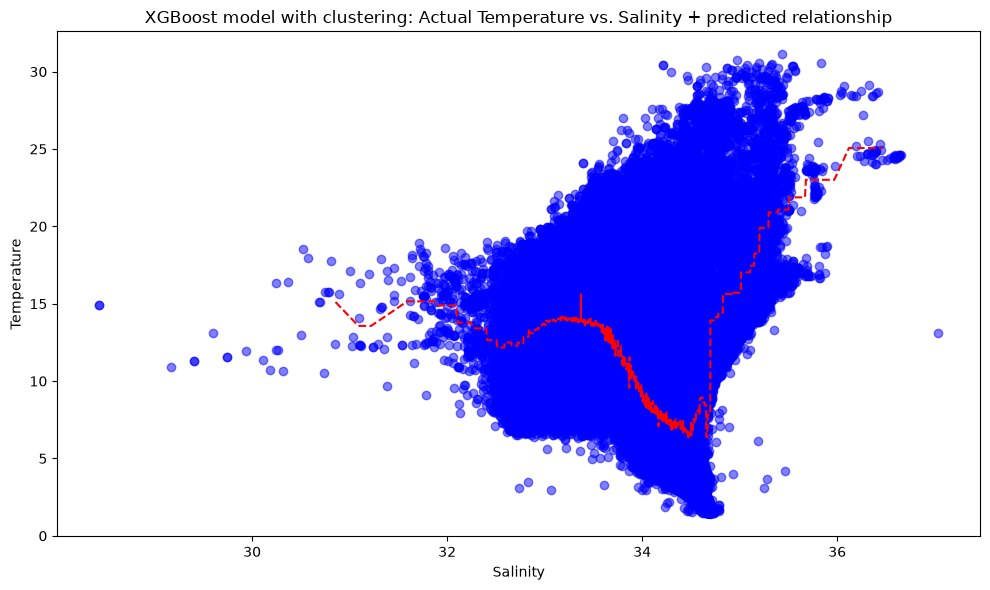

In [71]:
plt.figure(figsize = (10,6))
plt.scatter(x = X_train['Salnty'], y = y_train, color = 'blue', alpha = 0.5)
plt.plot(plot_data_kmeans_xgb['Salnty'], plot_data_kmeans_xgb['y_pred'], '--r')
plt.xlabel('Salinity')
plt.ylabel('Temperature')
plt.title('XGBoost model with clustering: Actual Temperature vs. Salinity + predicted relationship')
plt.tight_layout()
plt.show()

In [72]:
results_kmeans_xgb_train = []
y_train_pred_kmeans_xgb = kmeans_xgb_pipeline_best.predict(X_train)
results_kmeans_xgb_train.append({
    'n-nodes': 12,
    'r2_kmeans_xgb': r2_score(y_train, y_train_pred_kmeans_xgb),
    'rmse_kmeans_xgb': mean_squared_error(y_train, y_train_pred_kmeans_xgb) ** 0.5,
    'mae_kmeans_xgb': mean_absolute_error(y_train, y_train_pred_kmeans_xgb)
})

results_kmeans_xgb_train_df = pd.DataFrame(results_kmeans_xgb_train)

In [73]:
print('Metrics of the XGBoost model with K-means on the Validation set:')
display(results_kmeans_xgb_val_df)
print('Metrics of the XGBoost model with K-means on the Train set:')
display(results_kmeans_xgb_train_df)

Metrics of the XGBoost model with K-means on the Validation set:


,n-nodes,r2_kmeans_xgb,rmse_kmeans_xgb,mae_kmeans_xgb
0,12,0.440332,3.17582,2.280066


Metrics of the XGBoost model with K-means on the Train set:


,n-nodes,r2_kmeans_xgb,rmse_kmeans_xgb,mae_kmeans_xgb
0,12,0.441627,3.172574,2.277937


The close training, validation, and test metrics do not indicate substantial overfitting in this evaluation.

Let us save the model.

In [74]:
joblib.dump(kmeans_xgb_pipeline_best, "kmeans_xgboos_pipeline.pkl")

['kmeans_xgboos_pipeline.pkl']

Let us try neural network.

In [75]:
%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
X_train = X_train.drop(columns = ['Salnty_cluster'])
X_val = X_val.drop(columns = ['Salnty_cluster'])

In [77]:
print(X_train.isnull().sum())
print(X_val.isnull().sum())

Salnty    27782
dtype: int64
Salnty    5879
dtype: int64


In [78]:
imputer = SimpleImputer()

In [79]:
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)


In [80]:
normalizer = tf.keras.layers.Normalization(axis = -1)
normalizer.adapt(X_train_imp)
model_nn = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'linear')
])


In [81]:
model_nn.compile(
    optimizer = 'adam',
    loss = 'mse'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)

In [82]:
history = model_nn.fit(
    X_train_imp,
    y_train,
    validation_data = (X_val_imp, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop],
    verbose=1
)

Epoch 1/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 11.0829 - val_loss: 10.3195
Epoch 2/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 10.3272 - val_loss: 10.2890
Epoch 3/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 10.3047 - val_loss: 10.2825
Epoch 4/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 10.2901 - val_loss: 10.2823
Epoch 5/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 10.2780 - val_loss: 10.2795
Epoch 6/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 10.2699 - val_loss: 10.2855
Epoch 7/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - loss: 10.2647 - val_loss: 10.2860
Epoch 8/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - loss: 10.2598 - val_loss: 10.2974
Epoch 9/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - loss: 10.2554 - val_loss: 10.3061
Epoch 10/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - loss: 10.2513 - val_loss: 10.3045
Epoch 11/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step 

In [83]:
y_train_pred_nn = model_nn.predict(X_train_imp).ravel()
y_val_pred_nn = model_nn.predict(X_val_imp).ravel()

18680/18680 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [84]:
r2_train_nn = r2_score(y_train, y_train_pred_nn)
rmse_train_nn = mean_squared_error(y_train, y_train_pred_nn) ** 0.5
mae_train_nn = mean_absolute_error(y_train, y_train_pred_nn)

r2_val_nn = r2_score(y_val, y_val_pred_nn)
rmse_val_nn = mean_squared_error(y_val, y_val_pred_nn) ** 0.5
mae_val_nn = mean_absolute_error(y_val, y_val_pred_nn)

In [85]:
print('Train:')
print(f'R2: {r2_train_nn}')
print(f'RMSE: {rmse_train_nn}')
print(f'MAE: {mae_train_nn}')

print('\nValidation:')
print(f'R2: {r2_val_nn}')
print(f'RMSE: {rmse_val_nn}')
print(f'MAE: {mae_val_nn}')

Train:
R2: 0.4295780062675476
RMSE: 3.2066217456084805
MAE: 2.3174521923065186

Validation:
R2: 0.42958664894104004
RMSE: 3.2061635561587205
MAE: 2.3178582191467285


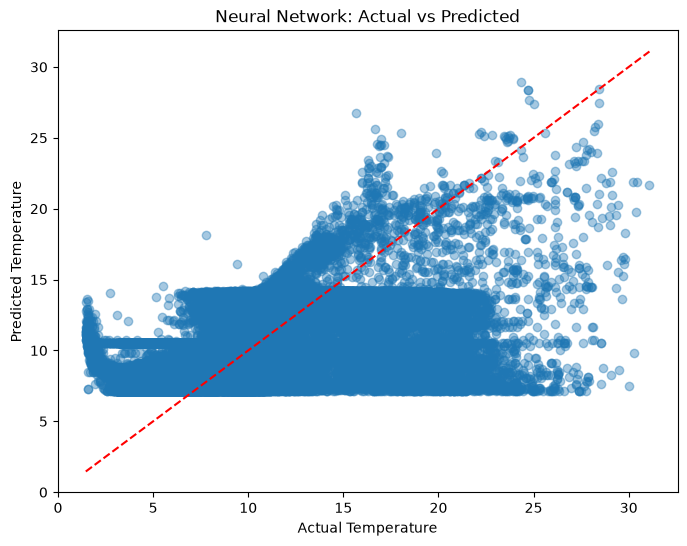

In [86]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_val_pred_nn, alpha=0.4)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--'
)

plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Neural Network: Actual vs Predicted')

plt.show()

In [87]:
model_nn.save("temp_by_salnty_3.keras")

Let us build up a neural network with 4 layers.

In [88]:
model_nn_3hl = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'linear')
])

In [89]:
model_nn_3hl.compile(
    optimizer = 'adam',
    loss = 'mse'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)

In [90]:
history_3hl = model_nn_3hl.fit(
    X_train_imp,
    y_train,
    validation_data = (X_val_imp, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop],
    verbose=1
)

Epoch 1/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 74s 4ms/step - loss: 10.7615 - val_loss: 10.3004
Epoch 2/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 75s 4ms/step - loss: 10.3518 - val_loss: 10.2782
Epoch 3/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - loss: 10.3185 - val_loss: 10.2934
Epoch 4/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 10.2952 - val_loss: 10.2864
Epoch 5/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 10.2791 - val_loss: 10.2886
Epoch 6/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - loss: 10.2661 - val_loss: 10.2801
Epoch 7/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 10.2544 - val_loss: 10.2865
Epoch 8/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 73s 4ms/step - loss: 10.2457 - val_loss: 10.3014
Epoch 9/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 10.2389 - val_loss: 10.3062
Epoch 10/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - loss: 10.2337 - val_loss: 10.3102
Epoch 11/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step 

In [91]:
model_nn_3hl = tf.keras.models.load_model('model_nn_3hl.keras')

In [92]:
y_train_pred_nn_3hl = model_nn_3hl.predict(X_train_imp).ravel()
y_val_pred_nn_3hl = model_nn_3hl.predict(X_val_imp).ravel()

18680/18680 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [93]:
r2_train_nn_3hl = r2_score(y_train, y_train_pred_nn_3hl)
rmse_train_nn_3hl = mean_squared_error(y_train, y_train_pred_nn_3hl) ** 0.5
mae_train_nn_3hl = mean_absolute_error(y_train, y_train_pred_nn_3hl)

r2_val_nn_3hl = r2_score(y_val, y_val_pred_nn_3hl)
rmse_val_nn_3hl = mean_squared_error(y_val, y_val_pred_nn_3hl) ** 0.5
mae_val_nn_3hl = mean_absolute_error(y_val, y_val_pred_nn_3hl)

In [94]:
print('Train:')
print(f'R2: {r2_train_nn_3hl}')
print(f'RMSE: {rmse_train_nn_3hl}')
print(f'MAE: {mae_train_nn_3hl}')

print('\nValidation:')
print(f'R2: {r2_val_nn_3hl}')
print(f'RMSE: {rmse_val_nn_3hl}')
print(f'MAE: {mae_val_nn_3hl}')

Train:
R2: 0.43152081966400146
RMSE: 3.201156383428043
MAE: 2.3018903732299805

Validation:
R2: 0.4317591190338135
RMSE: 3.2000522668861553
MAE: 2.3005855083465576


In [95]:
model_nn_3hl.save('model_nn_3hl.keras')

**Conclusion.**

There is a nonlinear relationship between salinity and water temperature. Using salinity as the only feature, the XGBoost model gives the best results among the models tested, with an R^2 of approximately 0.44, meaning that it explains about 44% of the variation in water temperature. To obtain more precise predictions, additional relevant features should be included in the model. Notably, that K-means clustering didn't give us any improvement in metrics.

In [96]:
print('Metrics of XGBoost model with K-means clustering:')
display(results_kmeans_xgb_bestModel1.iloc[0:1,1:])

Metrics of XGBoost model with K-means clustering:


,r2_kmeans_xgb,rmse_kmeans_xgb,mae_kmeans_xgb
6,0.440242,3.176078,2.279296


**Task 2. — Predicting Water Temperature Using Multiple Features.**

The task is to investigate the relationship between water temperature and multiple features, including salinity, depth, and dissolved oxygen, and determine whether water temperature can be predicted more accurately using these features compared with using salinity alone.

In [97]:
df_tsd.head()

,Depthm,Salnty,T_degC,O2ml_L
0,0,33.440,10.50,NaN
1,8,33.440,10.46,NaN
2,10,33.437,10.46,NaN
3,19,33.420,10.45,NaN
4,20,33.421,10.45,NaN


In [98]:
df_copy = df_tsd.copy()

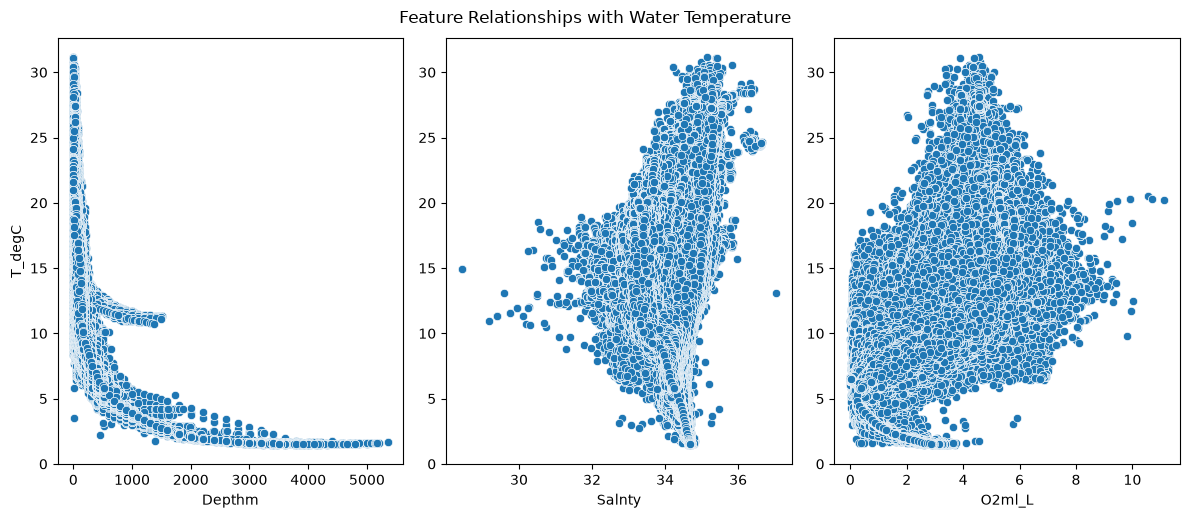

In [99]:
fig = plt.figure(figsize = (12,5))
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)
sns.scatterplot(data = df_copy, x = 'Depthm', y = 'T_degC', ax = ax0)
sns.scatterplot(data = df_copy, x = 'Salnty', y = 'T_degC', ax = ax1)
sns.scatterplot(data = df_copy, x = 'O2ml_L', y = 'T_degC', ax = ax2)
ax1.set_ylabel('')
ax2.set_ylabel('')
fig.text(0.5, 1, 'Feature Relationships with Water Temperature', ha = 'center', fontsize = 12)
plt.tight_layout()
plt.show()

As shown above LinearRegression isn't the most appropriate model for predicting Temperature.

In [100]:
df_copy.corr()

,Depthm,Salnty,T_degC,O2ml_L
Depthm,1.000000,0.572630,-0.681201,-0.592399
Salnty,0.572630,1.000000,-0.505266,-0.823870
T_degC,-0.681201,-0.505266,1.000000,0.795700
O2ml_L,-0.592399,-0.823870,0.795700,1.000000


We can see signs of multicollinearity between features.

To measure the non-linear dependency between variables, we employ Mutual Information (MI).

In [101]:
df_copy = df_copy.fillna(df_copy.median(numeric_only = True))

In [102]:
X = df_copy.copy()
y = X.pop('T_degC')

In [103]:
print(f'Missing values in X:\n{X.isnull().sum()}')
print(f'Missing values in y:\n{y.isnull().sum()}')

Missing values in X:
Depthm    0
Salnty    0
O2ml_L    0
dtype: int64
Missing values in y:
0


In [104]:
mi = mutual_info_regression(
    X,
    y,
    random_state = 1
)
mi_df = pd.DataFrame({
    'feature': X.columns,
    'MI': mi
})
mi_df

,feature,MI
0,Depthm,1.130211
1,Salnty,0.743515
2,O2ml_L,0.740744


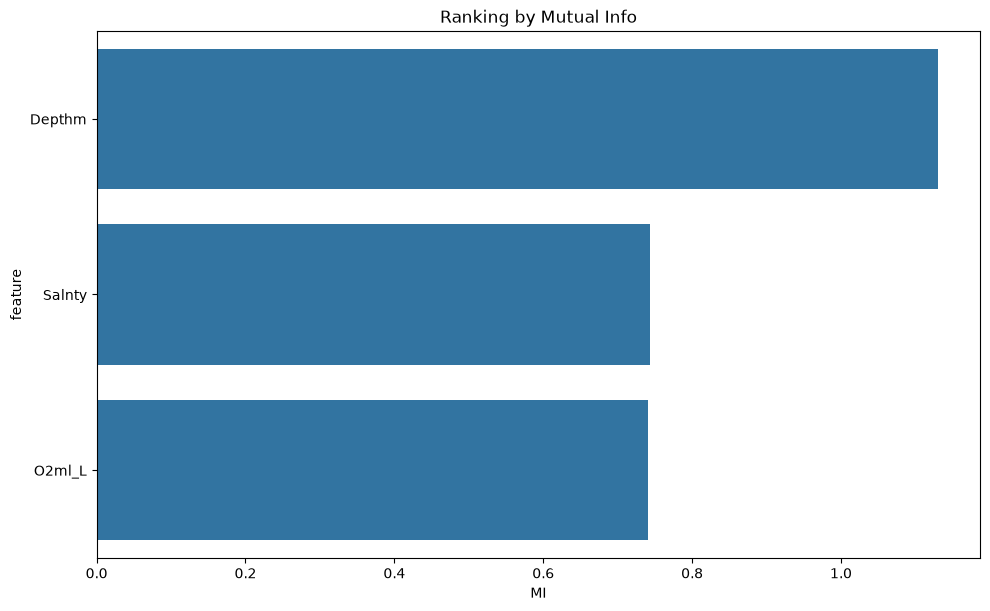

In [105]:
plt.figure(figsize=(10,6))
sns.barplot(data = mi_df, x = 'MI', y = 'feature')
plt.tight_layout()
plt.title('Ranking by Mutual Info')
plt.show()

Depth: 1.130  - Highest informativeness. It has the strogest relationship with the target variable and is the primary predictive feature.  
Salinity: 0.7435 - Moderate informativeness. It carries a significant amount of information, slightly exceeding that of dissolved oxygen.  
Dissolved Oxygen: 0.7407 - Moderate informativeness. Virtually equal to salinity in terms of predictive strength to the target variable.

When features show high multicollinearity, it is useful to check their pairwise Mutual Information score.

In [106]:
features = ['Depthm', 'Salnty', 'O2ml_L']
for target in features:
    predictors = [f for f in features if f != target]
    mi_f = mutual_info_regression(
        X[predictors],
        X[target],
        random_state = 42
    )
    print(f'\nTarget: {target}')
    for feature, value in zip(predictors, mi_f):
        print(f'{feature}: {value:.4f}')


Target: Depthm
Salnty: 0.7762
O2ml_L: 0.7674

Target: Salnty
Depthm: 0.7748
O2ml_L: 0.8991

Target: O2ml_L
Depthm: 0.7676
Salnty: 0.8979


Checking pairwise MI confirms high multicollinearity between Salnty and O2ml_L (MI = 0.90), showing they carry highly redundant information. While Depthm is also strongly coupled with both features (MI = 0.77), the salinity-oxygen pair presents the highest dependency.

Now let us check for outliers.

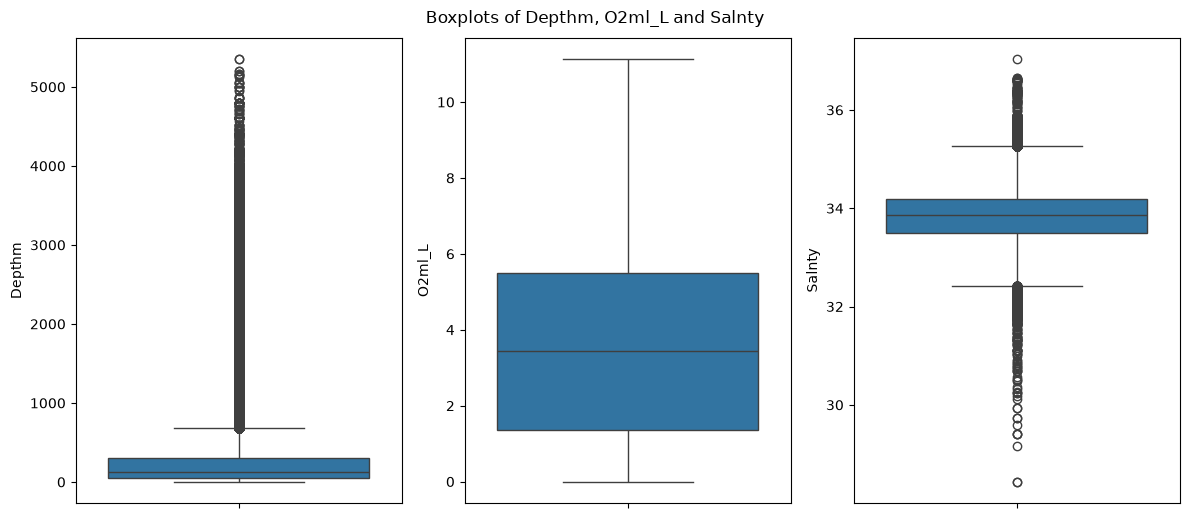

In [107]:
fig = plt.figure(figsize = (12,5))
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)
sns.boxplot(data = df_tsd, y = 'Depthm', ax = ax0)
sns.boxplot(data = df_tsd, y = 'O2ml_L', ax = ax1)
sns.boxplot(data = df_tsd, y = 'Salnty', ax = ax2)
fig.text(0.5, 1, 'Boxplots of Depthm, O2ml_L and Salnty', ha = 'center', fontsize = 12)
plt.tight_layout()
plt.show()

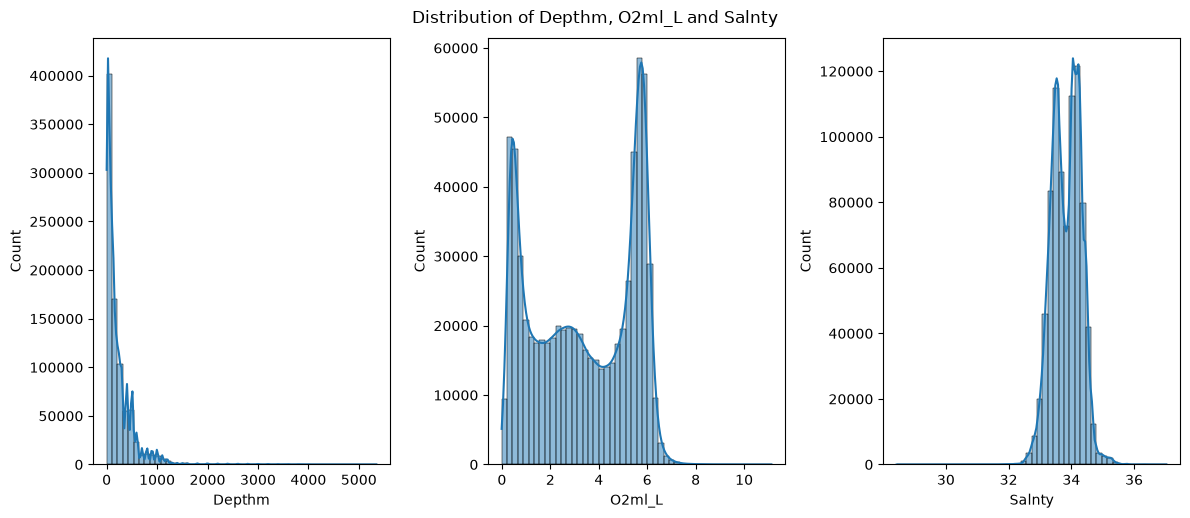

Skewness of Depthm: 4.503628275950327
Skewness of O2ml_L: -0.1222592151814389
Skewness of Salnty: -0.05176444376136519


In [108]:
fig = plt.figure(figsize = (12,5))
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)
sns.histplot(data = df_tsd, x = 'Depthm', bins = 50, kde = True, ax = ax0)
sns.histplot(data = df_tsd, x = 'O2ml_L', bins = 50, kde = True, ax = ax1)
sns.histplot(data = df_tsd, x = 'Salnty', bins = 50, kde = True, ax = ax2)
fig.text(0.5, 1, 'Distribution of Depthm, O2ml_L and Salnty', ha = 'center', fontsize = 12)
plt.tight_layout()
plt.show()
print(f'Skewness of Depthm: {df_tsd.Depthm.skew()}')
print(f'Skewness of O2ml_L: {df_tsd["O2ml_L"].skew()}')
print(f'Skewness of Salnty: {df_tsd["Salnty"].skew()}')

As can be seen from the plots, Depthm and Salnty contain statistical outliers. The distribution of Depthm exhibits a pronounced right tail, which can severely impair polynomial regression performance. Since most measurements are concentrated in the 0 – 900 m range with only sparse observations at depths of 2,000–5,000 m, generating polynomial features transforms these deep-water values into extremely large numbers. During the weight optimization process, these points can act as high-leverage observations, literally "pulling" the regression hyperplane toward themselves and distorting predictions for the vast majority of the data.  
**Furthermore, Depthm exhibits the highest Mutual Information (MI) score with T_degC compared to the other features. Consequently, applying the correct transformation to Depthm will have the most significant impact on overall model performance.**

Let us examine the statistical outliers of Depthm (I invistigated "Salnty" in the previous chapter) in more detail and find an appropriate way to mitigate the bias.

In [109]:
def outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [110]:
df_depth_outliers = outliers(df_tsd, 'Depthm')


In [111]:
df_depth_outliers.describe()

,Depthm,Salnty,T_degC,O2ml_L
count,54779.000000,46818.000000,54517.000000,39682.000000
mean,1117.715584,34.474659,3.982672,0.769913
std,592.129856,0.101767,1.045843,0.658232
min,682.000000,32.740000,1.440000,0.020000
25%,800.000000,34.414000,3.550000,0.400000
50%,939.000000,34.470000,4.090000,0.540000
75%,1116.000000,34.530000,4.600000,0.790000
max,5351.000000,35.462000,12.210000,5.770000


In [112]:
df_depth_outliers.shape[0]

54779

In [113]:
print('Max value of Depth outliers:')
display(df_depth_outliers.loc[df_depth_outliers.Depthm.idxmax()])
print('Min value of Depth outliers:')
display(df_depth_outliers.loc[df_depth_outliers.Depthm.idxmin()])

Max value of Depth outliers:


Depthm    5351.00
Salnty      34.68
T_degC       1.64
O2ml_L       3.52
Name: 466951, dtype: float64

Min value of Depth outliers:


Depthm    682.00
Salnty     34.40
T_degC      4.67
O2ml_L      0.39
Name: 21046, dtype: float64

In [114]:
display(bottle_df.loc[bottle_df.Depthm == 5351])
display(bottle_df.loc[bottle_df.Depthm == 682])

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
466951,18572,466952,056.0 333.0,19-7210AX-HY-291-0304-05603330-5351A-3,5351,1.64,34.68,3.52,27.779,45.0,...,NaN,5458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
467996,18599,467997,005.0 333.0,19-7210AX-HY-291-0304-00503330-5351A-3,5351,1.64,34.68,3.52,27.779,45.0,...,NaN,5458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
21046,687,21047,081.0 097.0,19-4909HO-HY-260-1436-08100970-0682A-3,682,4.67,34.400,0.39,27.243,5.4,...,NaN,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23909,776,23910,061.0 087.0,19-4910HO-HY-282-2342-06100870-0682A-3,682,4.52,34.350,0.49,27.220,6.8,...,NaN,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54026,1748,54027,090.0 053.0,19-5008CR-HY-230-1806-09000530-0682A-3,682,5.34,34.360,0.37,27.135,5.2,...,NaN,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57227,1849,57228,123.3 050.0,19-5009PT-HY-251-1936-12330500-0682A-3,682,5.14,34.450,0.40,27.230,5.6,...,NaN,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57909,1872,57910,110.0 035.0,19-5009PT-HY-260-0636-11000350-0682A-3,682,5.27,34.410,0.41,27.183,5.8,...,NaN,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77218,2578,77219,130.0 035.0,19-5103HO-HY-079-2048-13000350-0682A-3,682,5.96,NaN,0.25,NaN,NaN,...,NaN,688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79132,2642,79133,093.3 030.0,19-5104CR-HY-099-0830-09330300-0682A-3,682,5.18,NaN,0.34,NaN,NaN,...,NaN,688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97950,3292,97951,080.0 055.0,19-5109BD-HY-256-0248-08000550-0682A-3,682,4.87,NaN,0.37,NaN,NaN,...,NaN,688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98869,3329,98870,153.3 016.0,19-5109CR-HY-251-1136-15330160-0682A-3,682,5.80,34.640,0.22,27.301,3.2,...,NaN,686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104208,3564,104209,090.0 060.0,19-5111CR-HY-306-2306-09000600-0682A-3,682,4.88,NaN,0.35,NaN,NaN,...,NaN,688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
df_depth_outliers[df_depth_outliers.Depthm >= 4000][['Depthm', 'Salnty', 'O2ml_L', 'T_degC']].sample(20)

,Depthm,Salnty,O2ml_L,T_degC
467852,4000,34.670,3.18,1.52
640911,4059,34.690,3.29,1.49
199956,4381,34.780,3.56,1.51
280038,4065,34.600,2.46,1.60
440882,4761,34.692,3.48,1.56
467853,4066,34.670,3.18,1.52
324165,4023,34.683,3.20,1.48
373185,4145,NaN,NaN,1.54
466942,4200,34.680,3.44,1.49
640852,4000,34.687,3.21,1.50


In [116]:
df_tsd['Depthm'].describe(percentiles=[.25, .5, .75, .90, .95, .99])

count    864863.000000
mean        226.831951
std         316.050259
min           0.000000
25%          46.000000
50%         125.000000
75%         300.000000
90%         515.000000
95%         800.000000
99%        1300.000000
max        5351.000000
Name: Depthm, dtype: float64

In [117]:
df_tsd['Depthm'].quantile([0.5, 0.75, 0.90, 0.95, 0.98, 0.99, 0.995])

0.500     125.0
0.750     300.0
0.900     515.0
0.950     800.0
0.980    1100.0
0.990    1300.0
0.995    2000.0
Name: Depthm, dtype: float64

The Depthm column has statistical outliers, but since they aren't measurement errors, I'm keeping them.

In [118]:
imputer = SimpleImputer()
names = ['Depthm', 'O2ml_L', 'Salnty']
df_exp = df_tsd.copy()
df_exp[names] = imputer.fit_transform(df_exp[names])
for col in names:
    new = col + '_log'
    df_exp[new] = np.log1p(df_exp[col])
    print(f'Skewness of {new}: {df_exp[new].skew()}')

Skewness of Depthm_log: -0.9835056920917102
Skewness of O2ml_L_log: -0.8058221814145645
Skewness of Salnty_log: -0.09690053905959026


In [119]:
for col in names:
    new = col + '_yeojohnson'
    df_exp[new], _ = stats.yeojohnson(df_exp[col])
    print(f'Skewness of {new}: {df_exp[new].skew()}')

Skewness of Depthm_yeojohnson: -0.02224403142626123
Skewness of O2ml_L_yeojohnson: -0.19232468385679302
Skewness of Salnty_yeojohnson: 0.002101657748200831


In [120]:
qt = QuantileTransformer(output_distribution = 'normal', random_state = 7)
for col in names:
    new = col + '_QT'
    df_exp[new] = qt.fit_transform(df_exp[[col]])
    print(f'Skewness of {new}: {df_exp[new].skew()}')

Skewness of Depthm_QT: -1.7656344224846117
Skewness of O2ml_L_QT: -0.017085621656331765
Skewness of Salnty_QT: 0.008151020862062177


In [121]:
print(f'Skewness of Depthm before transformation: {df_exp["Depthm"].skew()}')
print(f'Skewness of Depthm after Yeo-Johnson transformation: {df_exp["Depthm_yeojohnson"].skew()}')

Skewness of Depthm before transformation: 4.503628275950327
Skewness of Depthm after Yeo-Johnson transformation: -0.02224403142626123


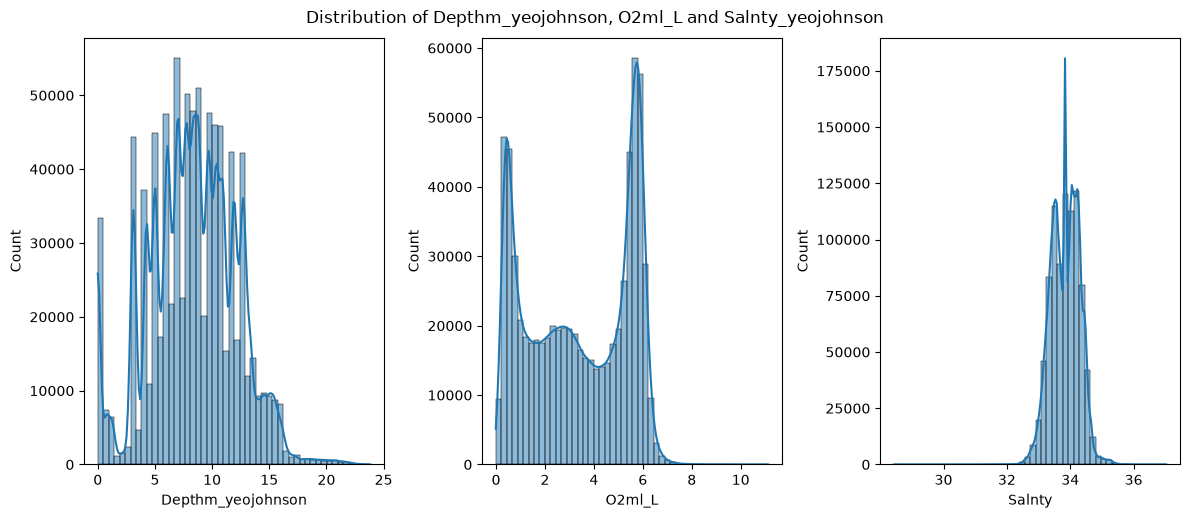

Skewness of Depthm_yeojohnson: -0.02224403142626123
Skewness of O2ml_L: -0.13626607874503383
Skewness of Salnty_yeojohnson: 0.002101657748200831


In [122]:
fig = plt.figure(figsize = (12,5))
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)
sns.histplot(data = df_exp, x = 'Depthm_yeojohnson', bins = 50, kde = True, ax = ax0)
sns.histplot(data = df_tsd, x = 'O2ml_L', bins = 50, kde = True, ax = ax1)
sns.histplot(data = df_exp, x = 'Salnty', bins = 50, kde = True, ax = ax2)
fig.text(0.5, 1, 'Distribution of Depthm_yeojohnson, O2ml_L and Salnty_yeojohnson', ha = 'center', fontsize = 12)
plt.tight_layout()
plt.show()
print(f'Skewness of Depthm_yeojohnson: {df_exp["Depthm_yeojohnson"].skew()}')
print(f'Skewness of O2ml_L: {df_exp["O2ml_L"].skew()}')
print(f'Skewness of Salnty_yeojohnson: {df_exp["Salnty_yeojohnson"].skew()}')

Let us start right with Polynomial Regression.

In [123]:
features = ['Depthm', 'O2ml_L', 'Salnty', 'T_degC']
df_f = bottle_df[features]
df_f.columns

Index(['Depthm', 'O2ml_L', 'Salnty', 'T_degC'], dtype='str')

In [124]:
df_f = df_f.dropna(subset = 'T_degC')
X_f = df_f
y_f = X_f.pop('T_degC')


In [125]:
print(X_f.columns)
print(y_f.name)

Index(['Depthm', 'O2ml_L', 'Salnty'], dtype='str')
T_degC


In [126]:
X_train, X_, y_train, y_ = train_test_split(X_f, y_f, test_size = 0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_, y_, test_size = 0.5, random_state=42)

This is a large dataset with 864863 rows and 4 columns. To save time and computational cost I'll reduce the original X_train dataset.

In [127]:
X_train_cut = X_train.sample(
    frac = 0.6,
    random_state = 42
)
y_train_cut = y_train[X_train_cut.index]

In [128]:
print(X_train_cut.shape[0])
print(y_train_cut.shape[0])

358638
358638


In [129]:
X_train.columns

Index(['Depthm', 'O2ml_L', 'Salnty'], dtype='str')

In [130]:
y_train.name

'T_degC'

In [131]:
preprocessor = ColumnTransformer([
    ('yeo', PowerTransformer(
        method='yeo-johnson',
        standardize=False
    ), [0]),

    ('passthrough', 'passthrough', [1, 2])
])

Justification for leaving Salnty and O2ml_L untransformed:  
Unlike Depthm, which exhibited severe right-skewness requiring variance stabilization, Salnty and O2ml_L operate within bounded physical ranges. They do not produce extreme high-leverage outliers during polynomial expansion.

In [132]:
poly_ridge_val_result = []
alphas = [1e-3, 0.01, 0.1, 1.0, 10.0, 20, 25, 30, 40, 50, 55, 60, 70, 100]

for n in range(2, 12):
    poly_ridge_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('transformer', preprocessor),
        ('pre-scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=n, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', RidgeCV(alphas=alphas))
    ])
    
    poly_ridge_pipeline.fit(X_train_cut, y_train_cut)
    y_val_pred = poly_ridge_pipeline.predict(X_val)

    poly_ridge_val_result.append({
        "degree": n,
        "Val_R^2": r2_score(y_val, y_val_pred),
        "Val_RMSE": mean_squared_error(y_val, y_val_pred) ** 0.5,
        "Val_MAE": mean_absolute_error(y_val, y_val_pred),
        "Best_Alpha": poly_ridge_pipeline.named_steps['regressor'].alpha_
    })

df_ridge_results = pd.DataFrame(poly_ridge_val_result)

In [133]:
df_ridge_results

,degree,Val_R^2,Val_RMSE,Val_MAE,Best_Alpha
0,2,0.821309,1.794494,1.255702,10.0
1,3,0.857770,1.600982,1.116607,30.0
2,4,0.866914,1.548661,1.033090,70.0
3,5,0.872681,1.514737,1.019958,100.0
4,6,0.876704,1.490612,0.980279,100.0
5,7,0.879886,1.471252,0.965835,100.0
6,8,0.880447,1.467812,0.957418,100.0
7,9,0.885076,1.439118,0.934207,10.0
8,10,0.883404,1.449551,0.931546,10.0
9,11,0.882387,1.455858,0.938355,30.0


In [134]:
df_ridge_best = df_ridge_results.loc[df_ridge_results['Val_R^2'] == df_ridge_results['Val_R^2'].max()]
df_ridge_best

,degree,Val_R^2,Val_RMSE,Val_MAE,Best_Alpha
7,9,0.885076,1.439118,0.934207,10.0


In [135]:
poly_ridge_pipeline_best = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('transformer', preprocessor),
    ('pre-scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=9, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', RidgeCV(alphas = 10))
])
    
poly_ridge_pipeline_best.fit(X_train_cut, y_train_cut)
y_val_pred = poly_ridge_pipeline_best.predict(X_val)

print(f'R^2 score: {r2_score(y_val, y_val_pred)}')
print(f'MSE score: {mean_squared_error(y_val, y_val_pred) ** 0.5}')
print(f'MAE: {mean_absolute_error(y_val, y_val_pred)}')

R^2 score: 0.8850758812991631
MSE score: 1.4391181030198652
MAE: 0.934207269888321


In [136]:
poly_ridge_train = []
y_train_pred = poly_ridge_pipeline_best.predict(X_train)

poly_ridge_train.append({
    "Train_R^2": r2_score(y_train, y_train_pred),
    "Train_MSE": mean_squared_error(y_train, y_train_pred) ** 0.5,
    "Train_MAE": mean_absolute_error(y_train, y_train_pred)
})
results_poly_train_df = pd.DataFrame(poly_ridge_train)
results_poly_train_df

,Train_R^2,Train_MSE,Train_MAE
0,0.859655,1.59055,0.931874


In [137]:
print('Metrics of the Validation set:')
display(df_ridge_best.iloc[:,1:])
print('Metrics of the Train set:')
display(results_poly_train_df)

Metrics of the Validation set:


,Val_R^2,Val_RMSE,Val_MAE,Best_Alpha
7,0.885076,1.439118,0.934207,10.0


Metrics of the Train set:


,Train_R^2,Train_MSE,Train_MAE
0,0.859655,1.59055,0.931874


The close training, validation, and test metrics do not indicate substantial overfitting in this evaluation.

In [138]:
joblib.dump(poly_ridge_pipeline_best, 'poly_ridge_features.pkl')

['poly_ridge_features.pkl']

XGBoost.

In [139]:
results_xgb_ftrs = []
for n in range(2,15):
    xgb_pipeline_ftrs = Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('regressor', XGBRegressor(
           n_estimators = 1000,
           max_depth = n,
           learning_rate = 0.01,
           subsample = 0.8,
           colsample_bytree = 0.8,
           random_state = 42 
        ))
    ])
    xgb_pipeline_ftrs.fit(X_train, y_train)
    y_val_pred_ftrs = xgb_pipeline_ftrs.predict(X_val)
    results_xgb_ftrs.append({
        'n_nodes': n,
        'Val_R^2': r2_score(y_val, y_val_pred_ftrs),
        'Val_RMSE': mean_squared_error(y_val, y_val_pred_ftrs) ** 0.5,
        'Val_MAE': mean_absolute_error(y_val, y_val_pred_ftrs)
    })
    results_xgb_val_df = pd.DataFrame(results_xgb_ftrs)



In [140]:
results_xgb_val_df

,n_nodes,Val_R^2,Val_RMSE,Val_MAE
0,2,0.874099,1.506276,1.018661
1,3,0.885619,1.435714,0.947063
2,4,0.891506,1.398278,0.915656
3,5,0.894886,1.376324,0.896736
4,6,0.897149,1.361429,0.882664
5,7,0.898264,1.354031,0.875651
6,8,0.898862,1.350043,0.871253
7,9,0.899105,1.348421,0.869294
8,10,0.899034,1.348897,0.868810
9,11,0.898648,1.351474,0.869803


In [141]:
results_xgb_val_best = results_xgb_val_df.loc[results_xgb_val_df['Val_R^2'] == results_xgb_val_df['Val_R^2'].max()]
results_xgb_val_best

,n_nodes,Val_R^2,Val_RMSE,Val_MAE
7,9,0.899105,1.348421,0.869294


In [142]:
results_xgb_ftrs_best = []
xgb_pipeline_ftrs_best = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('regressor', XGBRegressor(
        n_estimators = 1000,
        max_depth = 9,
        learning_rate = 0.01,
        subsample = 0.8,
        colsample_bytree = 0.8,
        random_state = 42 
        ))
    ])
xgb_pipeline_ftrs_best.fit(X_train, y_train)
y_val_pred_ftrs = xgb_pipeline_ftrs_best.predict(X_val)
results_xgb_ftrs_best.append({
    'n_nodes': 9,
    'Val_R^2': r2_score(y_val, y_val_pred_ftrs),
    'Val_RMSE': mean_squared_error(y_val, y_val_pred_ftrs) ** 0.5,
    'Val_MAE': mean_absolute_error(y_val, y_val_pred_ftrs)
    })
results_xgb_ftrs_best_df = pd.DataFrame(results_xgb_ftrs_best)


In [143]:
results_xgb_ftrs_best_df

,n_nodes,Val_R^2,Val_RMSE,Val_MAE
0,9,0.899105,1.348421,0.869294


In [144]:
results_xgb_ftrs_train = []
y_train_pred_ftrs = xgb_pipeline_ftrs_best.predict(X_train)
results_xgb_ftrs_train.append({
    'n_nodes': 9,
    'Val_R^2': r2_score(y_train, y_train_pred_ftrs),
    'Val_RMSE': mean_squared_error(y_train, y_train_pred_ftrs) ** 0.5,
    'Val_MAE': mean_squared_error(y_train, y_train_pred_ftrs)
    })
results_xgb_ftrs_train_df = pd.DataFrame(results_xgb_ftrs_train)


In [145]:
print(f'Metrics of the Validation set:')
display(results_xgb_ftrs_best_df)
print(f'Metrics of the Train set:')
display(results_xgb_ftrs_train_df)

Metrics of the Validation set:


,n_nodes,Val_R^2,Val_RMSE,Val_MAE
0,9,0.899105,1.348421,0.869294


Metrics of the Train set:


,n_nodes,Val_R^2,Val_RMSE,Val_MAE
0,9,0.904339,1.313156,1.724378


The close training, validation, and test metrics do not indicate substantial overfitting in this evaluation.

Let us apply K-means clustering and create a new feature.

In [146]:
train_median = X_train.median()
X_train_imp = X_train.fillna(train_median)
X_val_imp = X_val.fillna(train_median)
X_test_imp = X_test.fillna(train_median)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

In [147]:
kmeans_f = KMeans(n_clusters = 300, random_state = 42)
kmeans_f.fit(X_train_scaled)
X_train['Cluster'] = kmeans_f.labels_
X_val['Cluster'] = kmeans_f.predict(X_val_scaled)
X_test['Cluster'] = kmeans_f.predict(X_test_scaled)
X_train['Cluster'] = X_train['Cluster'].astype("category")
X_val['Cluster'] = X_val['Cluster'].astype("category")
X_test['Cluster'] = X_test['Cluster'].astype("category")

In [148]:
results_xgb_kmeans_f = []
for n in range(2,15):
    xgb_pipeline_kmeans_f = Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('regressor', XGBRegressor(
           n_estimators = 800,
           max_depth = n,
           learning_rate = 0.01,
           subsample = 0.8,
           colsample_bytree = 0.8,
           random_state = 42 
        ))
    ])
    xgb_pipeline_kmeans_f.fit(X_train, y_train)
    y_val_pred_kmeans_f = xgb_pipeline_kmeans_f.predict(X_val)
    results_xgb_kmeans_f.append({
        'n_nodes': n,
        'Val_R^2': r2_score(y_val, y_val_pred_kmeans_f),
        'Val_RMSE': mean_squared_error(y_val, y_val_pred_kmeans_f) ** 0.5,
        'Val_MAE': mean_absolute_error(y_val, y_val_pred_kmeans_f)
    })
    results_xgb_kmeans_val_df = pd.DataFrame(results_xgb_kmeans_f)

In [149]:
results_xgb_kmeans_val_df

,n_nodes,Val_R^2,Val_RMSE,Val_MAE
0,2,0.873545,1.509590,1.023864
1,3,0.885819,1.434460,0.953868
2,4,0.894396,1.379532,0.902204
3,5,0.899277,1.347273,0.871675
4,6,0.902601,1.324857,0.850855
5,7,0.904914,1.309031,0.834722
6,8,0.906326,1.299276,0.824340
7,9,0.907154,1.293517,0.817415
8,10,0.907631,1.290193,0.813353
9,11,0.907725,1.289531,0.811107


In [150]:
best_result_xgb_kmeans = results_xgb_kmeans_val_df.loc[results_xgb_kmeans_val_df['Val_R^2'] == results_xgb_kmeans_val_df['Val_R^2'].max()]
best_result_xgb_kmeans

,n_nodes,Val_R^2,Val_RMSE,Val_MAE
9,11,0.907725,1.289531,0.811107


In [151]:
results_xgb_kmeans_f_val = []
xgb_pipeline_kmeans_f_best = Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('regressor', XGBRegressor(
           n_estimators = 800,
           max_depth = 11,
           learning_rate = 0.01,
           subsample = 0.8,
           colsample_bytree = 0.8,
           random_state = 42 
        ))
])
xgb_pipeline_kmeans_f_best.fit(X_train, y_train)
y_val_pred_kmeans_f = xgb_pipeline_kmeans_f_best.predict(X_val)
results_xgb_kmeans_f_val.append({
    'n_nodes': 11,
    'Val_R^2': r2_score(y_val, y_val_pred_kmeans_f),
    'Val_RMSE': mean_squared_error(y_val, y_val_pred_kmeans_f) ** 0.5,
    'Val_MAE': mean_absolute_error(y_val, y_val_pred_kmeans_f)
    })
results_xgb_kmeans_val_df = pd.DataFrame(results_xgb_kmeans_f_val)

In [152]:
results_xgb_kmeans_f_train = []
y_train_pred_kmeans_f = xgb_pipeline_kmeans_f_best.predict(X_train)
results_xgb_kmeans_f_train.append({
    'n_nodes': 11,
    'Train_R^2': r2_score(y_train, y_train_pred_kmeans_f),
    'Train_RMSE': mean_squared_error(y_train, y_train_pred_kmeans_f) ** 0.5,
    'Train_MAE': mean_absolute_error(y_train, y_train_pred_kmeans_f)
    })
results_xgb_kmeans_train_df = pd.DataFrame(results_xgb_kmeans_f_train)

In [153]:
print(f'Metrics of the Validation set:')
display(results_xgb_kmeans_val_df)
print(f'Metrics of the Train set:')
display(results_xgb_kmeans_train_df)

Metrics of the Validation set:


,n_nodes,Val_R^2,Val_RMSE,Val_MAE
0,11,0.907725,1.289531,0.811107


Metrics of the Train set:


,n_nodes,Train_R^2,Train_RMSE,Train_MAE
0,11,0.917718,1.21787,0.772223


The close training, validation, and test metrics do not indicate substantial overfitting in this evaluation.

In [154]:
joblib.dump(xgb_pipeline_kmeans_f_best, 'xgb_pipeline_kmeans_f_best.pkl')

['xgb_pipeline_kmeans_f_best.pkl']

Neural network

In [155]:
normalizer = tf.keras.layers.Normalization(axis = -1)
normalizer.adapt(X_train_imp.to_numpy())
model_f = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'linear')
])
model_f.compile(
    optimizer = 'adam',
    loss = 'mse'
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)
history_f = model_f.fit(
    X_train_imp,
    y_train,
    validation_data = (X_val_imp, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 1
)
y_train_pred_nn_f = model_f.predict(X_train_imp).ravel()
y_val_pred_nn_f = model_f.predict(X_val_imp).ravel()

Epoch 1/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 2.6494 - val_loss: 1.9717
Epoch 2/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 1.9271 - val_loss: 1.9192
Epoch 3/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 1.8891 - val_loss: 1.8926
Epoch 4/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 1.8704 - val_loss: 1.8770
Epoch 5/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 1.8580 - val_loss: 1.8638
Epoch 6/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 1.8485 - val_loss: 1.8536
Epoch 7/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - loss: 1.8384 - val_loss: 1.8456
Epoch 8/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 1.8303 - val_loss: 1.8376
Epoch 9/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 1.8239 - val_loss: 1.8341
Epoch 10/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 1.8181 - val_loss: 1.8327
Epoch 11/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 1.8131 - val

In [156]:
y_train_pred_f_nn = model_f.predict(X_train_imp)
y_val_pred_f_nn = model_f.predict(X_val_imp)

18680/18680 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [157]:
results_val_train = []
results_val_train.append({
    'Val_R^2': r2_score(y_val, y_val_pred_f_nn),
    'Train_R^2': r2_score(y_train, y_train_pred_f_nn),
    'Val_RMSE': mean_squared_error(y_val, y_val_pred_f_nn) ** 0.5,
    'Train_RMSE': mean_squared_error(y_train, y_train_pred_f_nn) ** 0.5,
    'Val_MAE': mean_absolute_error(y_val, y_val_pred_f_nn),
    'Train_MAE': mean_absolute_error(y_train, y_train_pred_f_nn)
})

results_val_train_df = pd.DataFrame(results_val_train)
results_val_train_df

,Val_R^2,Train_R^2,Val_RMSE,Train_RMSE,Val_MAE,Train_MAE
0,0.902337,0.903612,1.326646,1.318135,0.84655,0.842217


In [158]:
model_f.save("temp_by_depth_salnity_O2_3nl.keras")

In [159]:
normalizer = tf.keras.layers.Normalization(axis = -1)
normalizer.adapt(X_train_imp.to_numpy())
model_f_4nl = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'linear')
])
model_f_4nl.compile(
    optimizer = 'adam',
    loss = 'mse'
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)
history_f_4nl = model_f_4nl.fit(
    X_train_imp,
    y_train,
    validation_data = (X_val_imp, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 1
)
y_train_pred_nn_f = model_f_4nl.predict(X_train_imp).ravel()
y_val_pred_nn_f = model_f_4nl.predict(X_val_imp).ravel()

Epoch 1/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - loss: 2.3817 - val_loss: 1.9463
Epoch 2/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - loss: 1.9054 - val_loss: 1.8885
Epoch 3/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - loss: 1.8698 - val_loss: 1.8455
Epoch 4/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - loss: 1.8486 - val_loss: 1.8264
Epoch 5/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - loss: 1.8314 - val_loss: 1.8148
Epoch 6/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 88s 5ms/step - loss: 1.8188 - val_loss: 1.8099
Epoch 7/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 1.8087 - val_loss: 1.7972
Epoch 8/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - loss: 1.7995 - val_loss: 1.7866
Epoch 9/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 1.7920 - val_loss: 1.7843
Epoch 10/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 70s 4ms/step - loss: 1.7858 - val_loss: 1.7768
Epoch 11/100
18680/18680 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - loss: 1.7798 - val

In [160]:
y_train_pred_f_4nn = model_f_4nl.predict(X_train_imp)
y_val_pred_f_4nn = model_f_4nl.predict(X_val_imp)

18680/18680 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step
4003/4003 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [161]:
results_val_train_4nl = []
results_val_train_4nl.append({
    'Val_R^2': r2_score(y_val, y_val_pred_f_4nn),
    'Train_R^2': r2_score(y_train, y_train_pred_f_4nn),
    'Val_RMSE': mean_squared_error(y_val, y_val_pred_f_4nn) ** 0.5,
    'Train_RMSE': mean_squared_error(y_train, y_train_pred_f_4nn) ** 0.5,
    'Val_MAE': mean_absolute_error(y_val, y_val_pred_f_4nn),
    'Train_MAE': mean_absolute_error(y_train, y_train_pred_f_4nn)
})

results_val_train_4nl_df = pd.DataFrame(results_val_train_4nl)
results_val_train_4nl_df

,Val_R^2,Train_R^2,Val_RMSE,Train_RMSE,Val_MAE,Train_MAE
0,0.901407,0.902697,1.332948,1.324379,0.850196,0.846168


In [162]:
model_f_4nl.save("model_f_4nl.keras")

So, our best model is XGBoost with K-means clustering. Now let us apply the test set to it.

In [163]:
res_all = []
y_pred_test = xgb_pipeline_kmeans_f_best.predict(X_test)
y_pred_val = xgb_pipeline_kmeans_f_best.predict(X_val)
y_pred_train = xgb_pipeline_kmeans_f_best.predict(X_train)
res_all.append({
    'Val_R2': r2_score(y_val, y_pred_val),
    'Train_R2': r2_score(y_train, y_pred_train),
    'Test_R2': r2_score(y_test, y_pred_test),
    'Val_RMSE': mean_squared_error(y_val, y_pred_val) ** 0.5,
    'Train_RMSE': mean_squared_error(y_train, y_pred_train) ** 0.5,
    'Test_RMSE': mean_squared_error(y_test, y_pred_test) ** 0.5,
    'Val_MAE': mean_absolute_error(y_val, y_pred_val),
    'Train_MAE': mean_absolute_error(y_train, y_pred_train),
    'Test_MAE': mean_absolute_error(y_test, y_pred_test),
    'Val_MAE': mean_absolute_error(y_val, y_pred_val),
    'Train_MAE': mean_absolute_error(y_train, y_pred_train),
    'Test_MAE': mean_absolute_error(y_test, y_pred_test)
})
res_all_df = pd.DataFrame(res_all)


In [164]:
print('Metrics of the best model, XGBoost with K-means clustering:')
display(res_all_df)

Metrics of the best model, XGBoost with K-means clustering:


,Val_R2,Train_R2,Test_R2,Val_RMSE,Train_RMSE,Test_RMSE,Val_MAE,Train_MAE,Test_MAE
0,0.907725,0.917718,0.907559,1.289531,1.21787,1.287221,0.811107,0.772223,0.809522


Text(0.5, 1.0, 'Residual distribution')

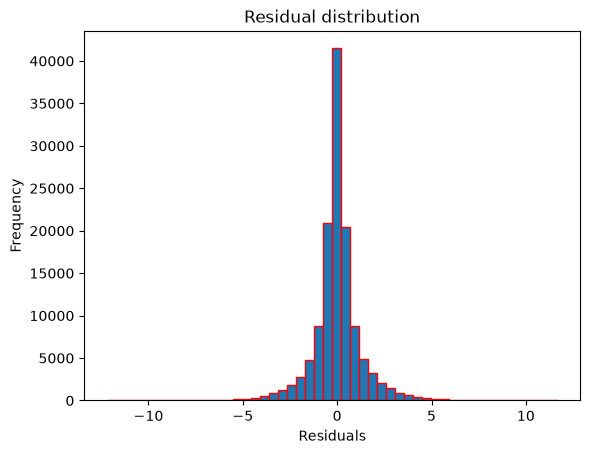

In [165]:
residuals = y_val - y_pred_val
plt.hist(residuals, bins = 50, edgecolor = 'red')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual distribution')

Text(0.5, 1.0, 'Residuals vs Predicted Values')

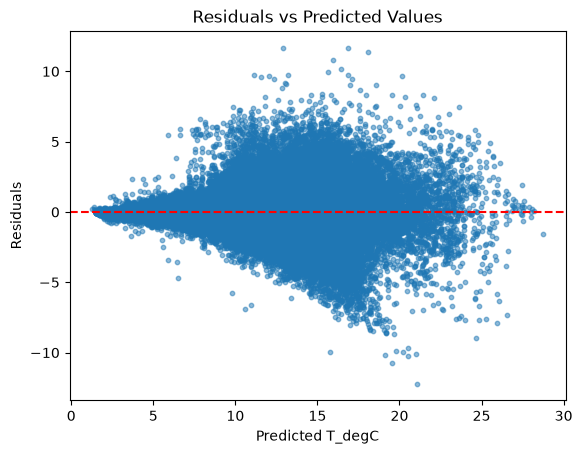

In [166]:
plt.scatter(y_pred_val, residuals, alpha = 0.5, s = 10)
plt.axhline(0, linestyle = '--', color = 'red')
plt.xlabel('Predicted T_degC')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')


As shown in the plot above, the residuals are fairly symmetrically distributed around the zero line across most of the range, though the variance in error isn't entirely constant.  
In the 10°C to 22°C range, there’s a noticeable arc-like pattern. This suggests there might be an uncaptured non-linear interaction or an underlying feature (like measurement location) that splits the data into sub-groups with different error patterns. That said, the residual distribution histogram shows no systematic bias, and on average, the model predicts temperature quite accurately. The vast majority of predictions (over 40,000 observations) have near-zero error, and the left and right tails taper off evenly, with no significant skew toward over- or under-prediction.  
Overall, the model delivers strong, consistent performance:  
- No overfitting (R^2 Train = 0.9177, R^2 Test = 0.9075, R^2, Validation = 0.9077)  
- The overwhelming majority of points are predicted with a minimal error of less than 1°C.